In [2]:
# Core dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
sns.set_theme(style="whitegrid")


DATA_DIR = Path("data")
YEARS = [2024, 2025, 2026]

def read_hdx_csv(path, usecols=None):
 """Read Humanitarian Data eXchange exported CSVs (skip schema row, handle BOM)."""
 return pd.read_csv(path, skiprows=[1], encoding="utf-8-sig", usecols=usecols, low_memory=False)

def split_pipe_list(x):
 """Split pipe-separated strings into lists."""
 if pd.isna(x):
    return []
 return [p.strip() for p in str(x).split("|") if p.strip()]

def format_num(n):
 """Format large numbers for readability."""
 if n >= 1e9: 
   return f"{n/1e9:.1f}B"
 if n >= 1e6: 
   return f"{n/1e6:.1f}M"
 if n >= 1e3: 
   return f"{n/1e3:.0f}K"
 return str(int(n))

## 1. Data Loading

**Data Sources Used:**
- **HPC HNO (2024-2026)** — Humanitarian needs data: Population, In Need, Targeted by country/cluster
- **Humanitarian Response Plans** — Funding requirements per country/year
- **INFORM Severity Index (2020-2025)** — Crisis severity, drivers, and trends
- **COD Population Statistics** — Country population baselines

**Why these datasets?** They provide the complete picture of need (HNO) vs resources (HRP) while INFORM adds context on WHY crises occur and their severity.

In [2]:
hno = pd.read_csv(
   DATA_DIR / f"hpc_hno_2025.csv", 
   skiprows=[1], 
   encoding="utf-8-sig", 
   usecols=None, 
   low_memory=False
 )

hno.shape

(318259, 16)

In [3]:
# Load HNO data (humanitarian needs by country/year)
HNO_COLS = ["Country ISO3", "Description", "Cluster", "Category", "Population", "In Need", "Targeted"]

hno = pd.concat([
 read_hdx_csv(DATA_DIR / f"hpc_hno_{y}.csv", usecols=HNO_COLS).assign(year=y)
 for y in YEARS
], ignore_index=True)

# Convert numeric columns
for c in ["Population", "In Need", "Targeted"]:
 hno[c] = pd.to_numeric(hno[c], errors="coerce")

# Data summary
hno_summary = pd.DataFrame({
 "Metric": ["Total Records", "Years Covered", "Countries"],
 "Value": [f"{len(hno):,}", f"{sorted(hno['year'].unique())}", hno['Country ISO3'].nunique()]
})

display(hno_summary.style.hide(axis="index"))

Metric,Value
Total Records,"706,211"
Years Covered,"[np.int64(2024), np.int64(2025), np.int64(2026)]"
Countries,24


In [4]:
hno.head()

,Country ISO3,Description,Cluster,Category,Population,In Need,Targeted,year
0,AFG,Final HNRP Caseload,ALL,NaN,44532600.0,23666389.0,17327995.0,2024
1,AFG,Final HNRP Caseload,ALL,Adult,NaN,10876422.0,7982696.0,2024
2,AFG,Final HNRP Caseload,ALL,Adult - Female,NaN,5857561.0,4090179.0,2024
3,AFG,Final HNRP Caseload,ALL,Adult - Female - Border / EC,NaN,184946.0,164215.0,2024
4,AFG,Final HNRP Caseload,ALL,Adult - Female - IDP,NaN,34726.0,26347.0,2024


In [4]:
# Load HRP data (humanitarian response plans - funding requirements)
HRP_COLS = ["code", "startDate", "endDate", "locations", "years", "origRequirements", "revisedRequirements"]
hrp = read_hdx_csv(DATA_DIR / "humanitarian-response-plans.csv", usecols=HRP_COLS)

for c in ["origRequirements", "revisedRequirements"]:
 hrp[c] = pd.to_numeric(hrp[c], errors="coerce")

hrp["startDate"] = pd.to_datetime(hrp["startDate"], errors="coerce")
hrp["endDate"] = pd.to_datetime(hrp["endDate"], errors="coerce")
hrp["loc_list"] = hrp["locations"].apply(split_pipe_list)
hrp["year_list"] = hrp["years"].apply(split_pipe_list)
hrp["n_locations"] = hrp["loc_list"].map(len)

# Data summary
hrp_summary = pd.DataFrame({
 "Metric": ["Total Plans", "Single-Country Plans", "Total Requirements (USD)"],
 "Value": [f"{len(hrp):,}", f"{(hrp['n_locations'] == 1).sum():,}", f"${hrp['revisedRequirements'].sum()/1e9:.1f}B"]
})
display(hrp_summary.style.hide(axis="index"))


Metric,Value
Total Plans,910
Single-Country Plans,811
Total Requirements (USD),$552.0B


In [6]:
hrp.head()

,code,startDate,endDate,locations,years,origRequirements,revisedRequirements,loc_list,year_list,n_locations
0,HHTI26,2026-01-01,2026-12-31,HTI,2026,880327426,880327426,[HTI],[2026],1
1,RREG26,2026-01-01,2026-12-31,YEM | KEN | DJI | SOM | ETH | TZA,2026,0,52990581,"[YEM, KEN, DJI, SOM, ETH, TZA]",[2026],6
2,FPSE26,2026-01-01,2026-12-31,PSE,2026,4064305808,4064305808,[PSE],[2026],1
3,HMLI26,2026-01-01,2026-12-31,MLI,2026,0,551000000,[MLI],[2026],1
4,OPAK26,2026-01-01,2026-04-30,PAK,2026,0,64943909,[PAK],[2026],1


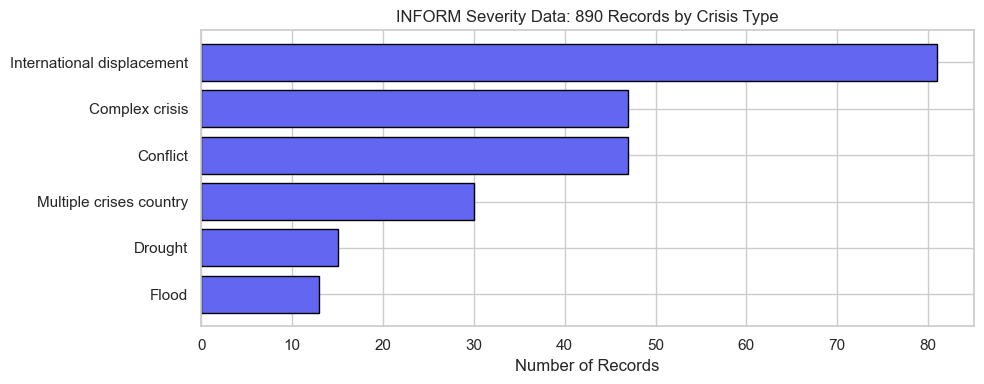

In [57]:
# Load INFORM Severity Index (enriches analysis with crisis context)
inform_path = DATA_DIR / "inform_severity_master_2020_2025.csv"
inform_raw = pd.read_csv(inform_path, encoding="utf-8-sig", low_memory=False)

# Skip metadata rows
inform = inform_raw.iloc[2:].copy()

# Select and rename key columns
inform_cols = {
 "COUNTRY": "country_name",
 "ISO3": "iso3",
 "TYPE OF CRISIS": "crisis_type",
 "INFORM Severity Index": "severity_index",
 "INFORM Severity category.1": "severity_category",
 "Trend (last 3 months)": "trend",
 "Regions": "region",
 "Year": "year",
 "DRIVERS": "drivers",
 "Complexity of the crisis": "complexity",
 "Operating environment": "operating_env",
}

inform = inform[list(inform_cols.keys())].rename(columns=inform_cols)

for col in ["severity_index", "year", "complexity", "operating_env"]:
 inform[col] = pd.to_numeric(inform[col], errors="coerce")

def get_primary_driver(x):
 if pd.isna(x) or str(x).strip() == "":
    return "Unknown"
 return str(x).split(",")[0].strip()

inform["primary_driver"] = inform["drivers"].apply(get_primary_driver)
inform = inform[~inform["iso3"].str.contains(",", na=False)].copy()

# Keep a stable copy for later joins (other sections may reuse the name `inform`)
inform_master = inform.copy()

# Display crisis type distribution
fig, ax = plt.subplots(figsize=(10, 4))
crisis_counts = inform["crisis_type"].value_counts().head(6)
ax.barh(crisis_counts.index, crisis_counts.values, color="#6366f1", edgecolor="black")
ax.set_xlabel("Number of Records")
ax.set_title(f"INFORM Severity Data: {len(inform):,} Records by Crisis Type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
inform.head()

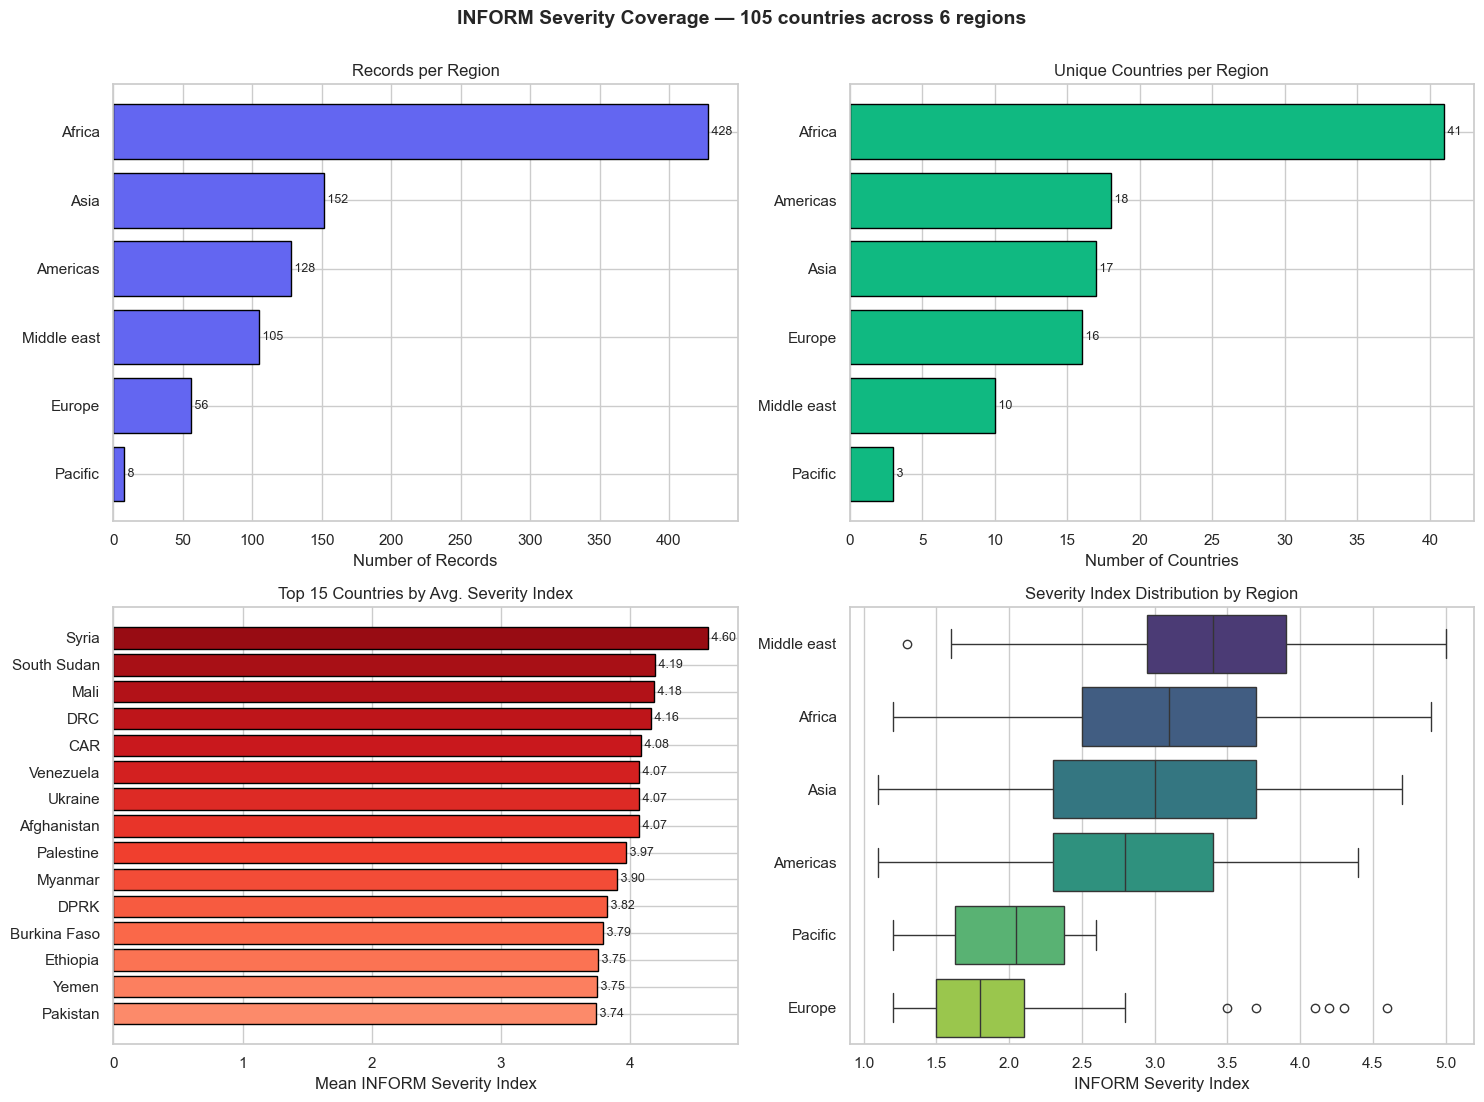


Coverage summary:
  Total countries: 105
  Total regions:   6
  Years covered:   [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [8]:
# Countries and Regions covered by INFORM Severity data
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- 1. Records per region ---
region_counts = (
    inform.dropna(subset=["region"])
          .groupby("region").size()
          .sort_values(ascending=True)
)
axes[0, 0].barh(region_counts.index, region_counts.values,
                color="#6366f1", edgecolor="black")
axes[0, 0].set_title("Records per Region")
axes[0, 0].set_xlabel("Number of Records")
for i, v in enumerate(region_counts.values):
    axes[0, 0].text(v, i, f" {v:,}", va="center", fontsize=9)

# --- 2. Unique countries per region ---
countries_per_region = (
    inform.dropna(subset=["region", "iso3"])
          .groupby("region")["iso3"].nunique()
          .sort_values(ascending=True)
)
axes[0, 1].barh(countries_per_region.index, countries_per_region.values,
                color="#10b981", edgecolor="black")
axes[0, 1].set_title("Unique Countries per Region")
axes[0, 1].set_xlabel("Number of Countries")
for i, v in enumerate(countries_per_region.values):
    axes[0, 1].text(v, i, f" {v}", va="center", fontsize=9)

# --- 3. Top 15 countries by average severity index ---
top_countries = (
    inform.dropna(subset=["severity_index", "country_name"])
          .groupby("country_name")["severity_index"].mean()
          .sort_values(ascending=False)
          .head(15)
          .sort_values(ascending=True)  # ascending for horizontal bar
)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_countries)))
axes[1, 0].barh(top_countries.index, top_countries.values,
                color=colors, edgecolor="black")
axes[1, 0].set_title("Top 15 Countries by Avg. Severity Index")
axes[1, 0].set_xlabel("Mean INFORM Severity Index")
for i, v in enumerate(top_countries.values):
    axes[1, 0].text(v, i, f" {v:.2f}", va="center", fontsize=9)

# --- 4. Severity index distribution by region ---
region_order = (
    inform.dropna(subset=["region", "severity_index"])
          .groupby("region")["severity_index"].median()
          .sort_values(ascending=False).index
)
sns.boxplot(
    data=inform.dropna(subset=["region", "severity_index"]),
    y="region", x="severity_index",
    order=region_order,
    ax=axes[1, 1], palette="viridis"
)
axes[1, 1].set_title("Severity Index Distribution by Region")
axes[1, 1].set_xlabel("INFORM Severity Index")
axes[1, 1].set_ylabel("")

plt.suptitle(
    f"INFORM Severity Coverage — {inform['iso3'].nunique()} countries across {inform['region'].nunique()} regions",
    fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.show()

# Print concise summary
print(f"\nCoverage summary:")
print(f"  Total countries: {inform['iso3'].nunique()}")
print(f"  Total regions:   {inform['region'].nunique()}")
print(f"  Years covered:   {sorted(inform['year'].dropna().astype(int).unique())}")

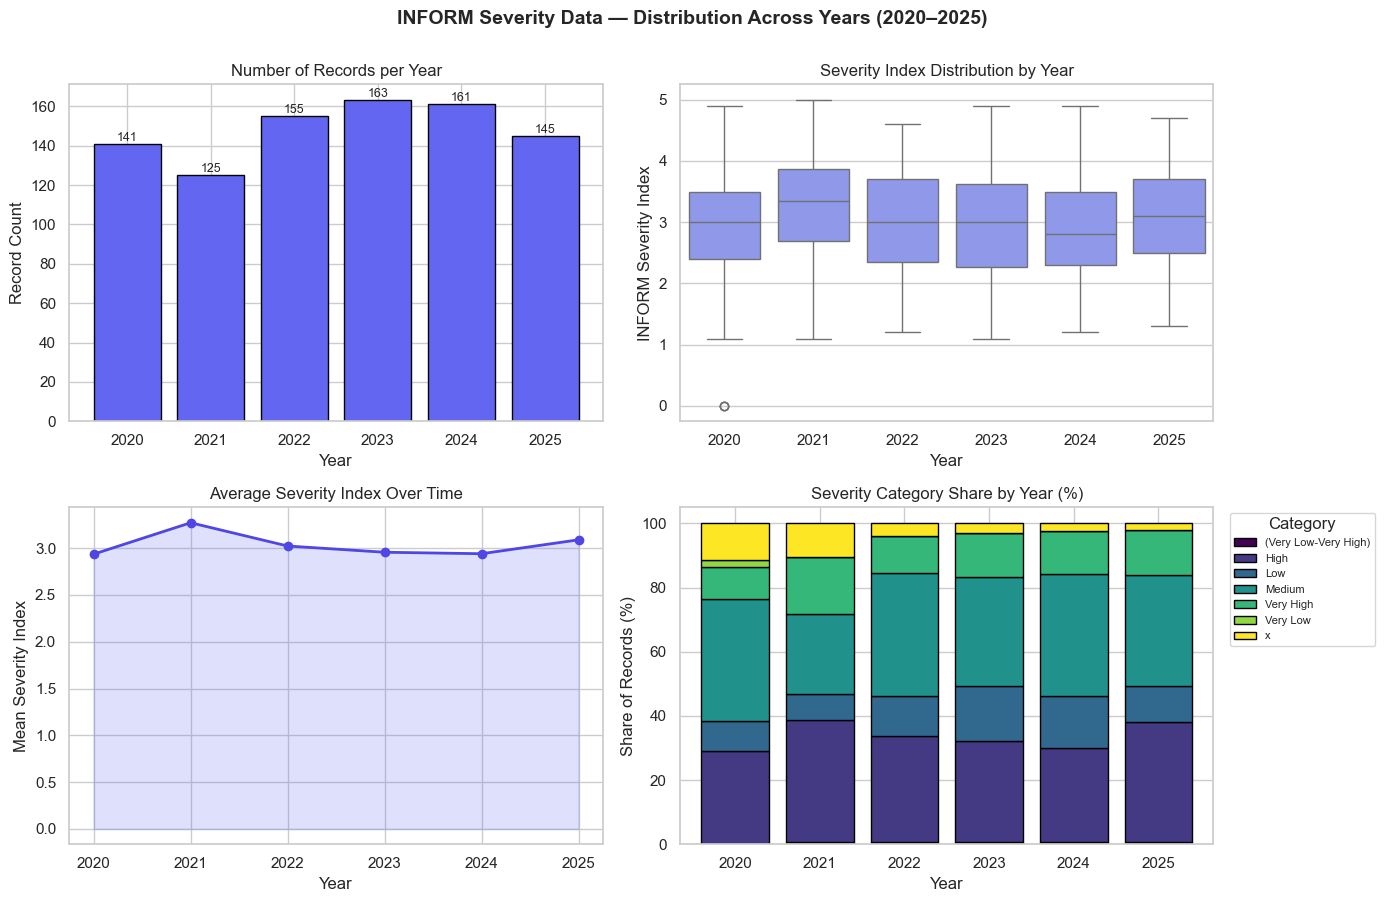

In [9]:
# Distribution of INFORM Severity data across years
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- 1. Record counts per year ---
year_counts = inform["year"].value_counts().sort_index()
axes[0, 0].bar(year_counts.index.astype(int), year_counts.values,
               color="#6366f1", edgecolor="black")
axes[0, 0].set_title("Number of Records per Year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Record Count")
for x, y in zip(year_counts.index.astype(int), year_counts.values):
    axes[0, 0].text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=9)

# --- 2. Severity index distribution by year (boxplot) ---
sns.boxplot(
    data=inform.dropna(subset=["severity_index", "year"]),
    x="year", y="severity_index",
    ax=axes[0, 1], color="#818cf8"
)
axes[0, 1].set_title("Severity Index Distribution by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("INFORM Severity Index")

# --- 3. Mean severity index trend ---
mean_sev = inform.groupby("year")["severity_index"].mean().sort_index()
axes[1, 0].plot(mean_sev.index.astype(int), mean_sev.values,
                marker="o", color="#4f46e5", linewidth=2)
axes[1, 0].fill_between(mean_sev.index.astype(int), mean_sev.values,
                        alpha=0.2, color="#6366f1")
axes[1, 0].set_title("Average Severity Index Over Time")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Mean Severity Index")

# --- 4. Severity category composition by year (stacked %) ---
cat_by_year = (
    inform.dropna(subset=["severity_category", "year"])
          .groupby(["year", "severity_category"]).size()
          .unstack(fill_value=0)
)
cat_pct = cat_by_year.div(cat_by_year.sum(axis=1), axis=0) * 100
cat_pct.plot(kind="bar", stacked=True, ax=axes[1, 1],
             colormap="viridis", edgecolor="black", width=0.8)
axes[1, 1].set_title("Severity Category Share by Year (%)")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Share of Records (%)")
axes[1, 1].legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1, 1].tick_params(axis="x", rotation=0)

plt.suptitle("INFORM Severity Data — Distribution Across Years (2020–2025)",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

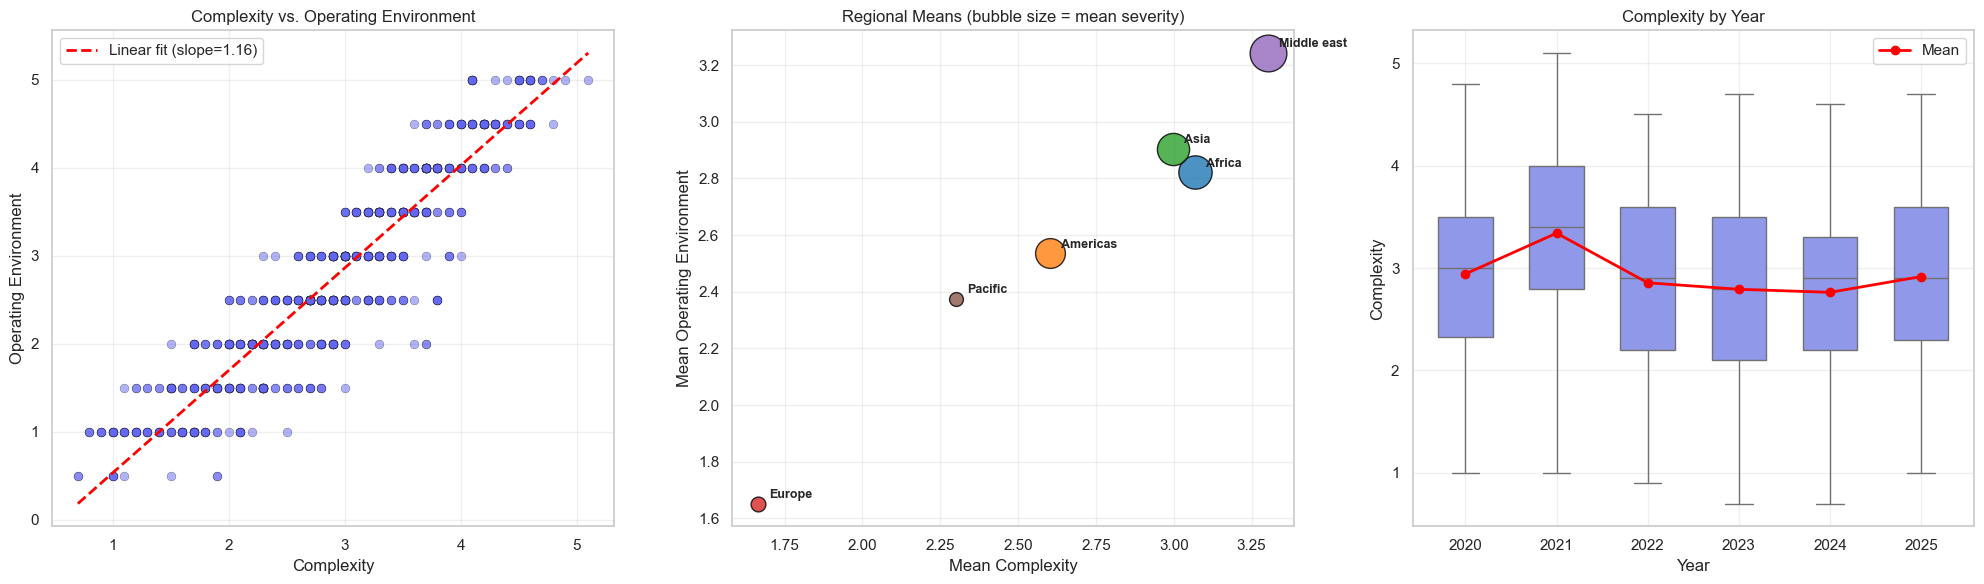

In [10]:
plot_df = inform.dropna(subset=["complexity", "operating_env", "region"]).copy()
plot_df["severity_index"] = pd.to_numeric(plot_df["severity_index"], errors="coerce")
plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce")

regions = sorted(plot_df["region"].unique())
palette = dict(zip(regions, sns.color_palette("tab10", n_colors=len(regions))))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: scatter of complexity vs operating environment ---
axes[0].scatter(
    plot_df["complexity"], plot_df["operating_env"],
    s=40, alpha=0.5, color="#6366f1",
    edgecolor="black", linewidth=0.3
)
axes[0].set_title("Complexity vs. Operating Environment")
axes[0].set_xlabel("Complexity")
axes[0].set_ylabel("Operating Environment")
axes[0].grid(True, alpha=0.3)

if plot_df[["complexity", "operating_env"]].dropna().shape[0] > 1:
    z = np.polyfit(plot_df["complexity"], plot_df["operating_env"], 1)
    xs = np.linspace(plot_df["complexity"].min(), plot_df["complexity"].max(), 100)
    axes[0].plot(xs, np.polyval(z, xs), color="red", linewidth=2,
                 linestyle="--", label=f"Linear fit (slope={z[0]:.2f})")
    axes[0].legend()

# --- Plot 2: regional means, bubble size = mean severity ---
agg = (
    plot_df.groupby("region")
           .agg(complexity=("complexity", "mean"),
                operating_env=("operating_env", "mean"),
                severity=("severity_index", "mean"),
                n=("iso3", "count"))
           .reset_index()
)

sev = agg["severity"].fillna(agg["severity"].mean())
sizes = 100 + (sev - sev.min()) / max(sev.max() - sev.min(), 1e-9) * 600

for i, row in agg.iterrows():
    axes[1].scatter(
        row["complexity"], row["operating_env"],
        s=sizes.iloc[i], color=palette[row["region"]],
        alpha=0.8, edgecolor="black", linewidth=1
    )
    axes[1].annotate(
        row["region"],
        (row["complexity"], row["operating_env"]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=9, fontweight="bold"
    )

axes[1].set_title("Regional Means (bubble size = mean severity)")
axes[1].set_xlabel("Mean Complexity")
axes[1].set_ylabel("Mean Operating Environment")
axes[1].grid(True, alpha=0.3)

# --- Plot 3: complexity over years ---
year_df = plot_df.dropna(subset=["year", "complexity"]).copy()
year_df["year"] = year_df["year"].astype(int)

sns.boxplot(
    data=year_df, x="year", y="complexity",
    ax=axes[2], color="#818cf8", width=0.6
)

# Overlay mean trend line
mean_by_year = year_df.groupby("year")["complexity"].mean().sort_index()
years_sorted = mean_by_year.index.tolist()
x_positions = range(len(years_sorted))
axes[2].plot(x_positions, mean_by_year.values,
             color="red", marker="o", linewidth=2,
             label="Mean", zorder=5)

axes[2].set_title("Complexity by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Complexity")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Data Preprocessing & Feature Engineering

Key preprocessing steps:
1) Extract "overall caseload" rows from HNO (Cluster='ALL', Category blank) for country-level totals
2) Filter HRP to single-country plans to avoid mis-attributing regional budgets
3) Join INFORM severity data to add crisis context
4) Engineer derived metrics: need_rate, coverage_rate, usd_per_person_in_need, share_gap, mismatch scores

**Handling Missing Values:**
- Population/In Need/Targeted: Drop rows with missing critical values (< 1% of data)
- revisedRequirements: Use 0 when missing (conservative — assumes no funding requested)
- INFORM severity: Use 2025 data for 2026 (most recent available)

**Key Column Selection:**
- `In Need` — Primary measure of humanitarian need
- `Population` — Denominator for need_rate calculation
- `revisedRequirements` — Best proxy for resource allocation (requested funding)
- `severity_index` — External validation of crisis severity

In [ ]:
#This cell shows the different types of values the cluster datapoint can take. Cluster specifies where the money is allocated.

# IASC humanitarian cluster code → full name mapping
CLUSTER_NAMES = {
    # Aggregate
    "ALL": "All Sectors",

    # Core technical clusters
    "WSH":  "Water, Sanitation and Hygiene",   # (WASH)
    "WASH": "Water, Sanitation and Hygiene",
    "NUT":  "Nutrition",
    "HEA":  "Health",
    "HEALTH": "Health",
    "EDU":  "Education",
    "FSC":  "Food Security",
    "FSL":  "Food Security and Livelihoods",
    "FS":   "Food Security",
    "AGR":  "Agriculture",                      # sometimes split from FSC

    # Shelter-related
    "SHL":     "Shelter",
    "SHELTER": "Shelter",
    "NFI":     "Non-Food Items",
    "S-NFI":   "Shelter and Non-Food Items",
    "SNFI":    "Shelter and Non-Food Items",
    "CCM":     "Camp Coordination and Camp Management",   # (CCCM)
    "CCCM":    "Camp Coordination and Camp Management",
    "SLSC":    "Shelter, Land and Site Coordination",

    # Protection cluster and its Areas of Responsibility (AoRs)
    "PRO":        "Protection",
    "PROT":       "Protection",
    "PROTECTION": "Protection",
    "PRO-GBV":    "Protection — Gender-Based Violence",
    "GBV":        "Gender-Based Violence",
    "PRO-CPN":    "Protection — Child Protection",
    "PRO-CP":     "Protection — Child Protection",
    "CP":         "Child Protection",
    "PRO-MIN":    "Protection — Mine Action",
    "MA":         "Mine Action",
    "PRO-HLP":    "Protection — Housing, Land and Property",
    "HLP":        "Housing, Land and Property",

    # Service clusters
    "LOG": "Logistics",
    "ETC": "Emergency Telecommunications",
    "TEL": "Emergency Telecommunications",   # (ETC)

    # Cross-cutting / other
    "ERY":   "Early Recovery",                 # (ER)
    "ER":    "Early Recovery",
    "EREC":  "Early Recovery",
    "MPC":   "Multi-Purpose Cash Assistance",  # (MPCA)
    "MPCA":  "Multi-Purpose Cash Assistance",
    "CVA":   "Cash and Voucher Assistance",
    "MS":    "Multi-Sector",                   # common in refugee contexts
    "CSS":   "Coordination and Support Services",
    "COORD": "Coordination",
    "RMS":   "Refugee and Migrant Support",
}

def cluster_full_name(code):
    """Return full cluster name, falling back to the code itself if unknown."""
    if pd.isna(code):
        return "Unknown"
    key = str(code).strip().upper()
    return CLUSTER_NAMES.get(key, str(code))

# --- Apply to the data ---
hno["cluster_name"] = hno["Cluster"].apply(cluster_full_name)

# Nice summary: counts per cluster with full name
cluster_summary = (
    hno.groupby(["Cluster", "cluster_name"])
       .size()
       .reset_index(name="records")
       .sort_values("records", ascending=False)
)
print("Cluster codes in HNO data:")
print(cluster_summary.to_string(index=False))

# --- Flag any codes still unmapped ---
unmapped = sorted(
    c for c in hno["Cluster"].dropna().unique()
    if str(c).strip().upper() not in CLUSTER_NAMES
)
if unmapped:
    print(f"\n⚠️  {len(unmapped)} cluster code(s) not in dictionary:")
    for c in unmapped:
        print(f"  - {c!r}")
else:
    print("\n✅ All cluster codes mapped.")

Cluster codes in HNO data:
Cluster                            cluster_name  records
    PRO                              Protection   109875
    FSC                           Food Security    66254
    ALL                             All Sectors    63866
PRO-GBV      Protection — Gender-Based Violence    61751
    WSH           Water, Sanitation and Hygiene    57802
    HEA                                  Health    57438
PRO-CPN           Protection — Child Protection    56411
    SHL                                 Shelter    48747
    NUT                               Nutrition    44249
    EDU                               Education    33953
PRO-MIN                Protection — Mine Action    31966
PRO-HLP Protection — Housing, Land and Property    30502
    CCM   Camp Coordination and Camp Management    16297
    AGR                             Agriculture     7290
    MPC           Multi-Purpose Cash Assistance     5143
     MS                            Multi-Sector     3662
    

People in Need by Cluster (all years combined):

  Protection                                         In Need:   464.6M   Targeted:   164.1M
  Food Security                                      In Need:   394.9M   Targeted:   216.2M
  Health                                             In Need:   361.7M   Targeted:   176.6M
  Water, Sanitation and Hygiene                      In Need:   345.9M   Targeted:   169.3M
  Shelter                                            In Need:   199.5M   Targeted:    62.2M
  Protection — Gender-Based Violence                 In Need:   169.5M   Targeted:    45.1M
  Nutrition                                          In Need:   153.0M   Targeted:    93.6M
  Education                                          In Need:   152.0M   Targeted:    55.3M
  Protection — Child Protection                      In Need:   148.5M   Targeted:    55.3M
  Protection — Mine Action                           In Need:   115.7M   Targeted:    34.7M
  Camp Coordination and Camp Ma

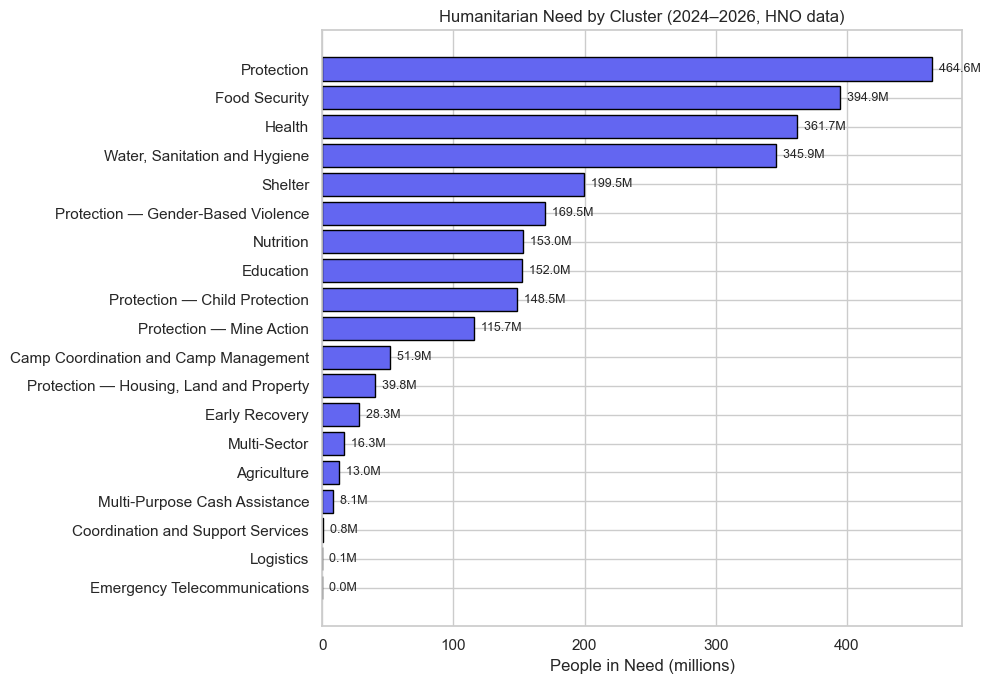

In [7]:
# People in Need by cluster (from HNO directly)
hno_by_cluster = (
    hno.query("Category == '' or Category != Category")  # top-level rows only
       .groupby(["Cluster", "cluster_name"], as_index=False)
       .agg(in_need=("In Need", "sum"),
            targeted=("Targeted", "sum"))
       .sort_values("in_need", ascending=False)
)

# Drop the "ALL" aggregate row so we don't double-count
hno_by_cluster = hno_by_cluster[hno_by_cluster["Cluster"] != "ALL"].reset_index(drop=True)

# Pretty print
print("People in Need by Cluster (all years combined):\n")
for _, r in hno_by_cluster.iterrows():
    print(f"  {r['cluster_name']:<50} In Need: {format_num(r['in_need']):>8}   Targeted: {format_num(r['targeted']):>8}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(hno_by_cluster["cluster_name"], hno_by_cluster["in_need"] / 1e6,
        color="#6366f1", edgecolor="black")
ax.set_xlabel("People in Need (millions)")
ax.set_title("Humanitarian Need by Cluster (2024–2026, HNO data)")
ax.invert_yaxis()
for i, v in enumerate(hno_by_cluster["in_need"] / 1e6):
    ax.text(v, i, f"  {v:.1f}M", va="center", fontsize=9)
plt.tight_layout()
plt.show()

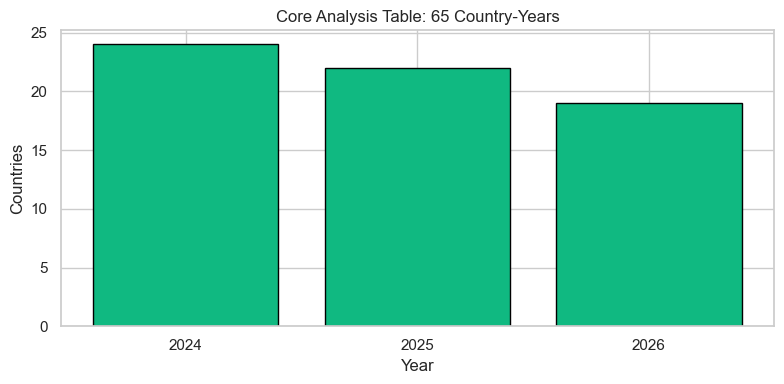

In [ ]:
# Build country-year analysis table (HNO need vs HRP requested resources)

# Country name mapping
COD0_COLS = ["ISO3", "Country"]
cod0 = read_hdx_csv(DATA_DIR / "cod_population_admin0.csv", usecols=COD0_COLS)
cod0 = cod0[~cod0["ISO3"].astype(str).str.startswith("#")].copy()
name_map = cod0.drop_duplicates("ISO3")[["ISO3", "Country"]].rename(columns={"ISO3": "iso3", "Country": "country"})

# Extract HNO overall caseload (Cluster='ALL', Category blank)
hno_clean = hno.copy()
hno_clean["Cluster"] = hno_clean["Cluster"].astype(str).str.strip()
hno_clean["Category"] = hno_clean["Category"].fillna("").astype(str).str.strip()

hno_overall = (
 hno_clean.query("Cluster == 'ALL' and Category == ''")
 .rename(columns={"Country ISO3": "iso3", "Population": "population", "In Need": "in_need", "Targeted": "targeted"})
 [["year", "iso3", "population", "in_need", "targeted"]].copy()
)

# HRP: aggregate to country-year, we don't look at plans involving multiple countries
hrp_single = hrp.query("n_locations == 1").copy()
hrp_single = hrp_single.explode("year_list")
hrp_single["year"] = pd.to_numeric(hrp_single["year_list"], errors="coerce")
hrp_single = hrp_single[hrp_single["year"].isin(YEARS)].copy()
hrp_single["year"] = hrp_single["year"].astype(int)
hrp_single["iso3"] = hrp_single["loc_list"].str[0]

hrp_agg = (
 hrp_single.assign(revisedRequirements=hrp_single["revisedRequirements"].fillna(0))
 .groupby(["year", "iso3"], as_index=False)
 .agg(req_sum=("revisedRequirements", "sum"), req_max=("revisedRequirements", "max"), n_plans=("code", "nunique"))
)

# Merge datasets
core = hno_overall.merge(hrp_agg, on=["year", "iso3"], how="left").merge(name_map, on="iso3", how="left")
core["country"] = core["country"].fillna(core["iso3"])
for c in ["req_sum", "req_max", "n_plans"]:
 core[c] = core[c].fillna(0)

# Summary visualization
plt.figure(figsize=(8, 4))

# Records by year
# The plot is jsut a sanity check to see if the conversion was alright, so don't worry about it
year_counts = core.groupby("year").size()
plt.bar(year_counts.index.astype(str), year_counts.values, color="#10b981", edgecolor="black")
plt.title(f"Core Analysis Table: {len(core)} Country-Years")
plt.xlabel("Year")
plt.ylabel("Countries")

plt.tight_layout()
plt.show()


In [15]:
core.describe()

,year,population,in_need,targeted,req_sum,req_max,n_plans
count,65.000000,6.500000e+01,6.500000e+01,6.500000e+01,6.500000e+01,6.500000e+01,65.000000
mean,2024.923077,4.268940e+07,9.536331e+06,5.438385e+06,1.258359e+09,1.245583e+09,1.076923
std,0.816006,4.891059e+07,7.911398e+06,4.827561e+06,1.068090e+09,1.066847e+09,0.321505
min,2024.000000,5.296124e+06,8.187000e+05,4.075000e+05,6.692345e+07,6.692345e+07,1.000000
25%,2024.000000,1.889363e+07,3.369526e+06,2.100146e+06,4.490000e+08,3.840000e+08,1.000000
50%,2025.000000,2.752278e+07,6.869716e+06,4.081412e+06,8.803274e+08,8.803274e+08,1.000000
75%,2026.000000,4.602435e+07,1.462230e+07,5.944709e+06,1.788817e+09,1.788817e+09,1.000000
max,2026.000000,2.375000e+08,3.369977e+07,2.093477e+07,4.209823e+09,4.162519e+09,3.000000


### Derived metrics (country-year)

We engineer the core signals used throughout the notebook:

- **Need intensity**: `need_rate = in_need / population`
- **Operational coverage**: `coverage_rate = targeted / in_need`
- **Resource adequacy (proxy)**: `usd_per_in_need = req_sum / in_need` (requested USD per person in need)
- **People gap**: `funding_gap_people = in_need - targeted`

To compare across countries **within a year** (robust to scale differences), we compute within-year percentile ranks:

- `need_rate_pct = pct_rank(need_rate)`
- `in_need_pct = pct_rank(in_need)`
- `usd_per_in_need_pct = pct_rank(usd_per_in_need)`

Then define mismatch-style scores:

- **Mismatch**: `mismatch = need_rate_pct - usd_per_in_need_pct` (high need + low resources ⇒ higher)
- **Severity proxy**: `severity_proxy_pct = 0.5 * need_rate_pct + 0.5 * in_need_pct`
- **Mismatch (severity proxy)**: `mismatch_severity_proxy = severity_proxy_pct - usd_per_in_need_pct`

**Important limitation**: `revisedRequirements` are *requested* resources, not confirmed disbursements. We treat them as a consistent proxy and validate patterns against INFORM severity/context.


In [16]:
# Derived metrics + robust percentile scores (computed within-year)

core = core.copy()

# Core ratios
core["need_rate"] = core["in_need"] / core["population"]
core["coverage_rate"] = core["targeted"] / core["in_need"]
core["usd_per_in_need"] = core["req_sum"] / core["in_need"]
core["usd_per_in_need_max"] = core["req_max"] / core["in_need"]
core["req_per_capita"] = core["req_sum"] / core["population"]
core["funding_gap_people"] = core["in_need"] - core["targeted"]

# Clean infinities
for c in ["need_rate", "coverage_rate", "usd_per_in_need", "usd_per_in_need_max", "req_per_capita"]:
 core.loc[~np.isfinite(core[c]), c] = np.nan

# Within-year shares
core["need_share"] = core.groupby("year")["in_need"].transform(lambda s: s / s.sum() if s.sum() else np.nan)
core["req_share"] = core.groupby("year")["req_sum"].transform(lambda s: s / s.sum() if s.sum() else np.nan)
core["share_gap"] = core["need_share"] - core["req_share"]

# Percentile ranks within each year
for raw, pct in {"need_rate": "need_rate_pct", "in_need": "in_need_pct", "usd_per_in_need": "usd_per_in_need_pct"}.items():
 core[pct] = core.groupby("year")[raw].rank(pct=True, method="average")

# Mismatch scores
core["severity_proxy_pct"] = 0.5 * core["need_rate_pct"] + 0.5 * core["in_need_pct"]
core["mismatch"] = core["need_rate_pct"] - core["usd_per_in_need_pct"]
core["mismatch_severity_proxy"] = core["severity_proxy_pct"] - core["usd_per_in_need_pct"]

# Log transforms
core["log10_in_need"] = np.log10(core["in_need"].where(core["in_need"] > 0))
core["log10_usd_per_in_need"] = np.log10(core["usd_per_in_need"].where(core["usd_per_in_need"] > 0))

# Summary statistics table
metrics_summary = core[["need_rate", "coverage_rate", "usd_per_in_need", "mismatch"]].describe().round(3)
display(metrics_summary.style.format("{:.3f}").set_caption("Key Metrics Summary"))


,need_rate,coverage_rate,usd_per_in_need,mismatch
count,65.000,65.000,65.000,65.000
mean,0.305,0.589,146.224,0.000
std,0.196,0.145,103.119,0.374
min,0.025,0.208,23.661,-0.909
25%,0.152,0.486,93.953,-0.273
50%,0.278,0.618,126.855,0.083
75%,0.461,0.694,177.230,0.273
max,0.723,0.841,721.940,0.737


# Assessing the first gap: does the severity according to the HNO correspond to the funds assigned by the HRP?

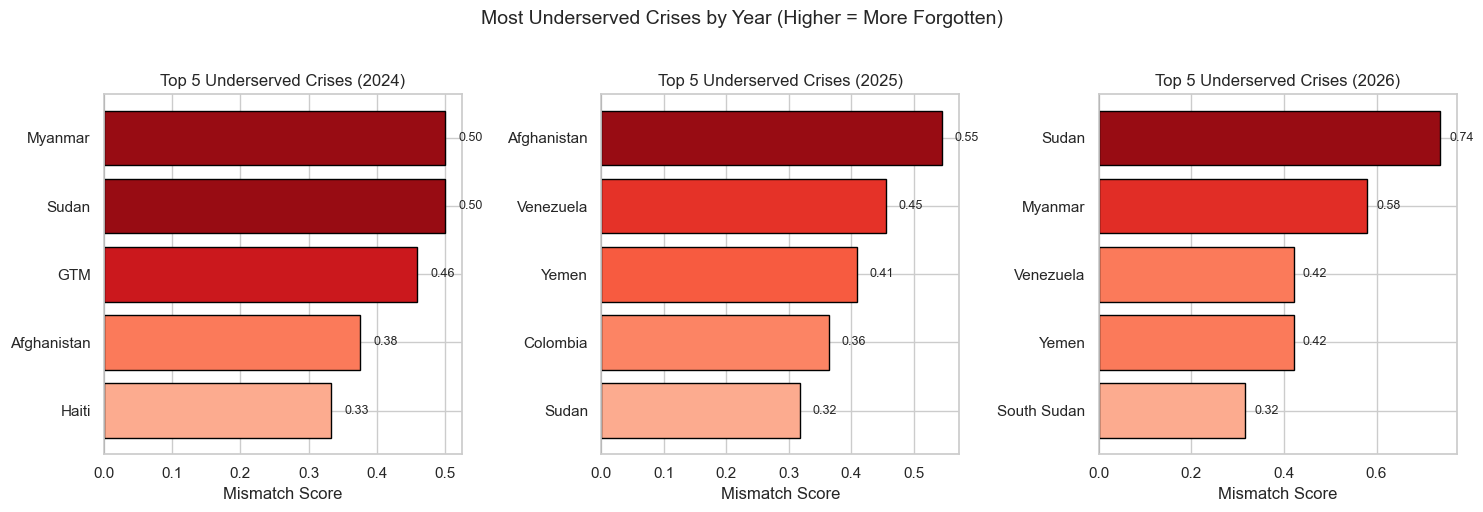

In [19]:
from matplotlib.colors import Normalize

# EDA: Top underserved crises by year (highest mismatch = most "forgotten")
# ISO3 to country name mapping
country_names = {
    "SDN": "Sudan", "MMR": "Myanmar", "AFG": "Afghanistan", "YEM": "Yemen",
    "SYR": "Syria", "COD": "DR Congo", "SSD": "South Sudan", "HTI": "Haiti",
    "VEN": "Venezuela", "COL": "Colombia", "NGA": "Nigeria", "MLI": "Mali",
    "ETH": "Ethiopia", "BGD": "Bangladesh", "PSE": "Palestine", "UKR": "Ukraine"
}
core["country"] = core["iso3"].map(country_names).fillna(core["iso3"])

# Create visualization: Top 5 underserved by year
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, year in enumerate(YEARS):
    ax = axes[idx]
    df_year = core[core["year"] == year].nlargest(5, "mismatch")

    # Map color intensity to mismatch value: higher mismatch → darker red
    norm = Normalize(vmin=df_year["mismatch"].min(),
                     vmax=df_year["mismatch"].max())
    colors = plt.cm.Reds(0.3 + 0.6 * norm(df_year["mismatch"]))

    bars = ax.barh(df_year["country"], df_year["mismatch"],
                   color=colors, edgecolor="black")
    ax.set_xlabel("Mismatch Score")
    ax.set_title(f"Top 5 Underserved Crises ({year})")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.invert_yaxis()  # worst at top

    # Add value labels
    for bar, val in zip(bars, df_year["mismatch"]):
        ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=9)

plt.suptitle("Most Underserved Crises by Year (Higher = More Forgotten)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

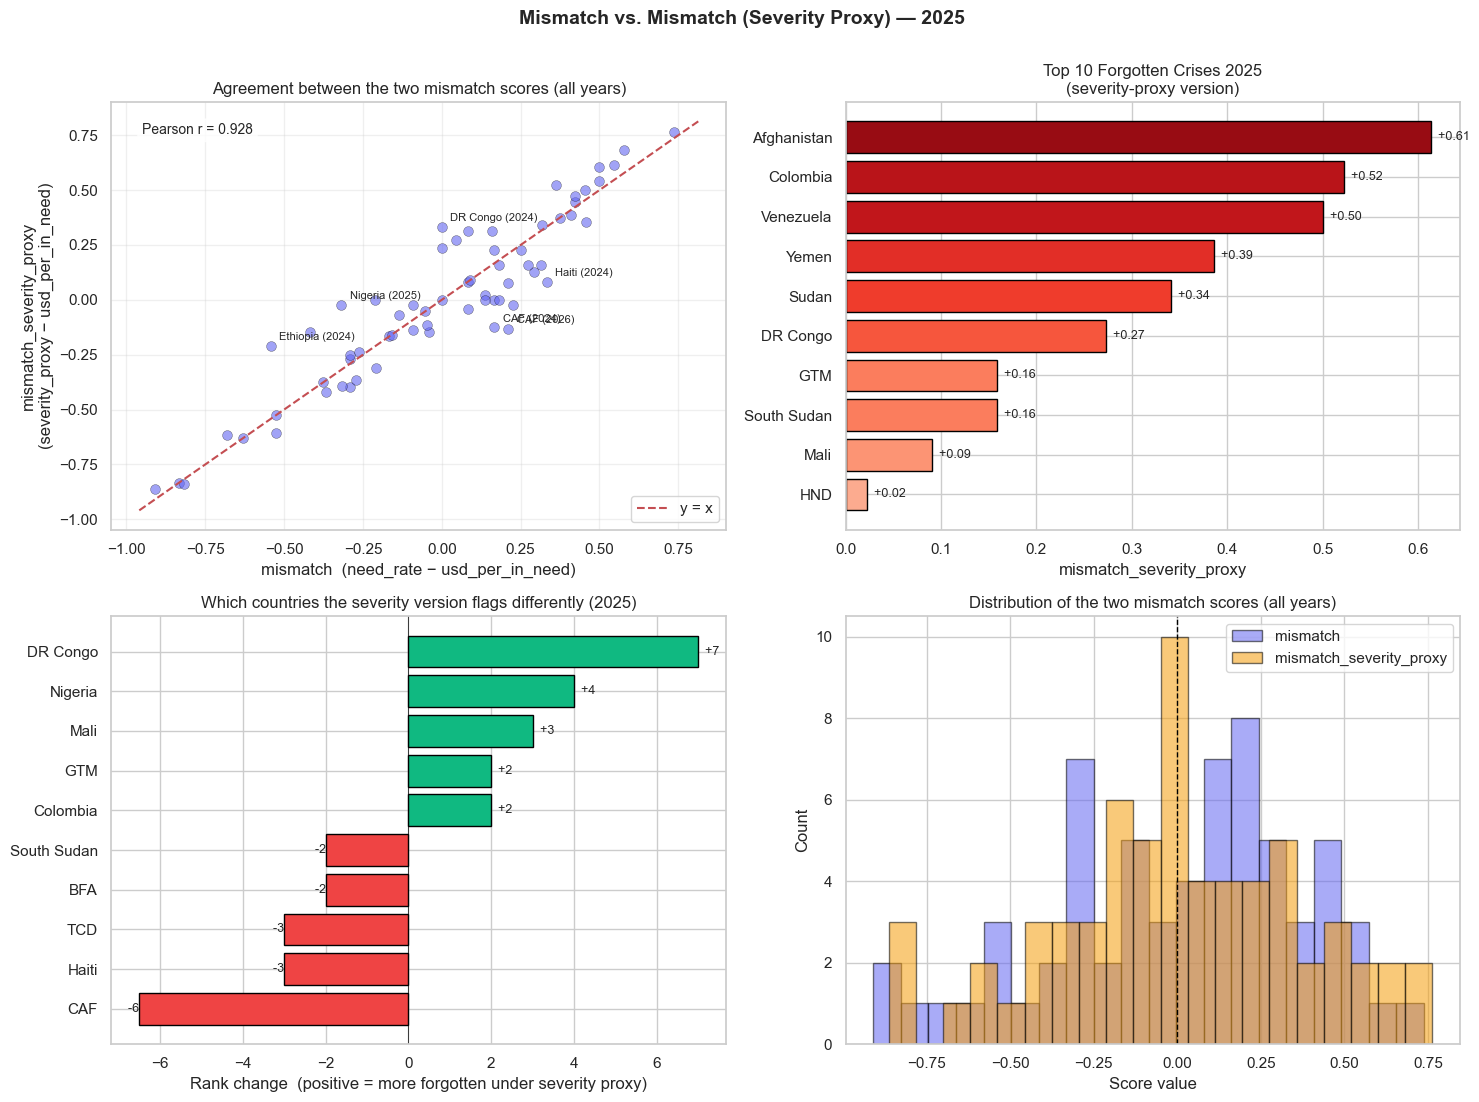


2025 top 10 by each score:

    country  mismatch  rank_mismatch  mismatch_severity_proxy  rank_severity
Afghanistan     0.545              1                    0.614              1
   Colombia     0.364              4                    0.523              2
  Venezuela     0.455              2                    0.500              3
      Yemen     0.409              3                    0.386              4
      Sudan     0.318              5                    0.341              5
   DR Congo     0.045             13                    0.273              6
        GTM     0.182              9                    0.159              7
South Sudan     0.273              6                    0.159              8
       Mali     0.091             12                    0.091              9
        HND     0.136             10                    0.023             10


In [31]:
from matplotlib.colors import Normalize


def compare_mismatch_scores(core, year):
    """Compare plain `mismatch` vs `mismatch_severity_proxy` for a given year.

    Renders a 2x2 figure: scatter agreement, top-10 forgotten crises under the
    severity version, ranking movers, and score distributions. Also prints a
    top-10 comparison table.

    Parameters
    ----------
    core : pd.DataFrame
        Must contain columns: mismatch, mismatch_severity_proxy, year, country.
    year : int
        Year to focus on for the year-specific panels (top-right, bottom-left,
        table). The scatter and histogram panels use all years.
    """
    plot_df = core.dropna(subset=["mismatch", "mismatch_severity_proxy"]).copy()
    year_df = plot_df[plot_df["year"] == year].copy()

    if year_df.empty:
        print(f"No data available for {year}.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    # --- 1. Scatter: how do the two scores compare? (all years) ---
    axes[0, 0].scatter(
        plot_df["mismatch"], plot_df["mismatch_severity_proxy"],
        s=50, alpha=0.6, color="#6366f1", edgecolor="black", linewidth=0.3
    )
    lim_min = min(plot_df["mismatch"].min(),
                  plot_df["mismatch_severity_proxy"].min()) - 0.05
    lim_max = max(plot_df["mismatch"].max(),
                  plot_df["mismatch_severity_proxy"].max()) + 0.05
    axes[0, 0].plot([lim_min, lim_max], [lim_min, lim_max],
                    "r--", linewidth=1.5, label="y = x")
    axes[0, 0].set_xlabel("mismatch  (need_rate − usd_per_in_need)")
    axes[0, 0].set_ylabel("mismatch_severity_proxy\n(severity_proxy − usd_per_in_need)")
    axes[0, 0].set_title("Agreement between the two mismatch scores (all years)")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Label the country-years with the biggest divergence
    plot_df["score_diff"] = plot_df["mismatch_severity_proxy"] - plot_df["mismatch"]
    movers = pd.concat([
        plot_df.nlargest(3, "score_diff"),
        plot_df.nsmallest(3, "score_diff"),
    ])
    for _, r in movers.iterrows():
        axes[0, 0].annotate(
            f"{r['country']} ({int(r['year'])})",
            (r["mismatch"], r["mismatch_severity_proxy"]),
            xytext=(6, 4), textcoords="offset points", fontsize=8
        )

    corr = plot_df[["mismatch", "mismatch_severity_proxy"]].corr().iloc[0, 1]
    axes[0, 0].text(
        0.05, 0.95, f"Pearson r = {corr:.3f}",
        transform=axes[0, 0].transAxes, fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    # --- 2. Top 10 most forgotten crises (severity proxy version) ---
    top10 = year_df.nlargest(10, "mismatch_severity_proxy")
    if top10["mismatch_severity_proxy"].nunique() > 1:
        norm = Normalize(vmin=top10["mismatch_severity_proxy"].min(),
                         vmax=top10["mismatch_severity_proxy"].max())
        colors = plt.cm.Reds(0.3 + 0.6 * norm(top10["mismatch_severity_proxy"]))
    else:
        colors = plt.cm.Reds([0.6] * len(top10))  # fallback if all equal

    axes[0, 1].barh(top10["country"], top10["mismatch_severity_proxy"],
                    color=colors, edgecolor="black")
    axes[0, 1].set_xlabel("mismatch_severity_proxy")
    axes[0, 1].set_title(f"Top 10 Forgotten Crises {year}\n(severity-proxy version)")
    axes[0, 1].invert_yaxis()
    for i, v in enumerate(top10["mismatch_severity_proxy"]):
        axes[0, 1].text(v, i, f"  {v:+.2f}", va="center", fontsize=9)

    # --- 3. How rankings differ between the two scores ---
    year_df["rank_mismatch"] = year_df["mismatch"].rank(ascending=False)
    year_df["rank_severity"] = year_df["mismatch_severity_proxy"].rank(ascending=False)
    year_df["rank_change"] = year_df["rank_mismatch"] - year_df["rank_severity"]

    movers_rank = year_df.reindex(
        year_df["rank_change"].abs().sort_values(ascending=False).index
    ).head(10).sort_values("rank_change")

    bar_colors = ["#10b981" if v > 0 else "#ef4444" for v in movers_rank["rank_change"]]
    axes[1, 0].barh(movers_rank["country"], movers_rank["rank_change"],
                    color=bar_colors, edgecolor="black")
    axes[1, 0].axvline(0, color="black", linewidth=0.5)
    axes[1, 0].set_xlabel("Rank change  (positive = more forgotten under severity proxy)")
    axes[1, 0].set_title(f"Which countries the severity version flags differently ({year})")
    for i, v in enumerate(movers_rank["rank_change"]):
        axes[1, 0].text(v, i, f"  {int(v):+d}",
                        va="center",
                        ha="left" if v >= 0 else "right",
                        fontsize=9)

    # --- 4. Distributions of the two scores (all years) ---
    axes[1, 1].hist(plot_df["mismatch"], bins=20, alpha=0.55,
                    label="mismatch", color="#6366f1", edgecolor="black")
    axes[1, 1].hist(plot_df["mismatch_severity_proxy"], bins=20, alpha=0.55,
                    label="mismatch_severity_proxy", color="#f59e0b", edgecolor="black")
    axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[1, 1].set_xlabel("Score value")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].set_title("Distribution of the two mismatch scores (all years)")
    axes[1, 1].legend()

    plt.suptitle(f"Mismatch vs. Mismatch (Severity Proxy) — {year}",
                 fontsize=14, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.show()

    # --- Compact comparison table ---
    print(f"\n{year} top 10 by each score:\n")
    comparison = (
        year_df.assign(
            rank_mismatch=lambda d: d["mismatch"].rank(ascending=False).astype(int),
            rank_severity=lambda d: d["mismatch_severity_proxy"].rank(ascending=False).astype(int),
        )
        .sort_values("rank_severity")
        .head(10)
        [["country", "mismatch", "rank_mismatch",
          "mismatch_severity_proxy", "rank_severity"]]
        .round(3)
    )
    print(comparison.to_string(index=False))



compare_mismatch_scores(core, 2025)

In [28]:
# Or with dtypes, more readable than info() for quick scanning:
print(core.dtypes.to_string())

year                         int64
iso3                           str
population                 float64
in_need                    float64
targeted                   float64
req_sum                      int64
req_max                      int64
n_plans                      int64
country                        str
need_rate                  float64
coverage_rate              float64
usd_per_in_need            float64
usd_per_in_need_max        float64
req_per_capita             float64
funding_gap_people         float64
need_share                 float64
req_share                  float64
share_gap                  float64
need_rate_pct              float64
in_need_pct                float64
usd_per_in_need_pct        float64
severity_proxy_pct         float64
mismatch                   float64
mismatch_severity_proxy    float64
log10_in_need              float64
log10_usd_per_in_need      float64


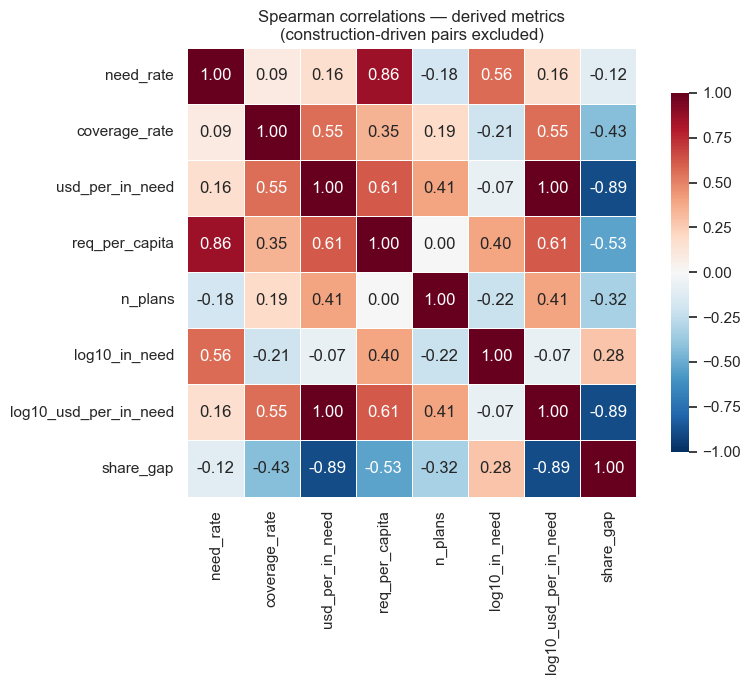


Strongest correlations (by |r|):
                 var1                  var2      corr
      usd_per_in_need log10_usd_per_in_need  1.000000
log10_usd_per_in_need             share_gap -0.891434
      usd_per_in_need             share_gap -0.891434
            need_rate        req_per_capita  0.855682
       req_per_capita log10_usd_per_in_need  0.614117
      usd_per_in_need        req_per_capita  0.614117
            need_rate         log10_in_need  0.562937
        coverage_rate       usd_per_in_need  0.554939
        coverage_rate log10_usd_per_in_need  0.554939
       req_per_capita             share_gap -0.534834
        coverage_rate             share_gap -0.428409
              n_plans log10_usd_per_in_need  0.406160
      usd_per_in_need               n_plans  0.406160
       req_per_capita         log10_in_need  0.398427
        coverage_rate        req_per_capita  0.349170
              n_plans             share_gap -0.323878
        log10_in_need             share_gap  0.2

In [29]:
interesting_cols = [
    "need_rate", "coverage_rate", "usd_per_in_need",
    "req_per_capita", "n_plans",
    "log10_in_need", "log10_usd_per_in_need",
    "share_gap",
]

corr = core[interesting_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Spearman correlations — derived metrics\n(construction-driven pairs excluded)")
plt.tight_layout()
plt.show()

# Also print the top non-trivial correlations ranked by strength
corr_long = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
        .sort_values("corr", key=abs, ascending=False)
)
print("\nStrongest correlations (by |r|):")
print(corr_long.to_string(index=False))

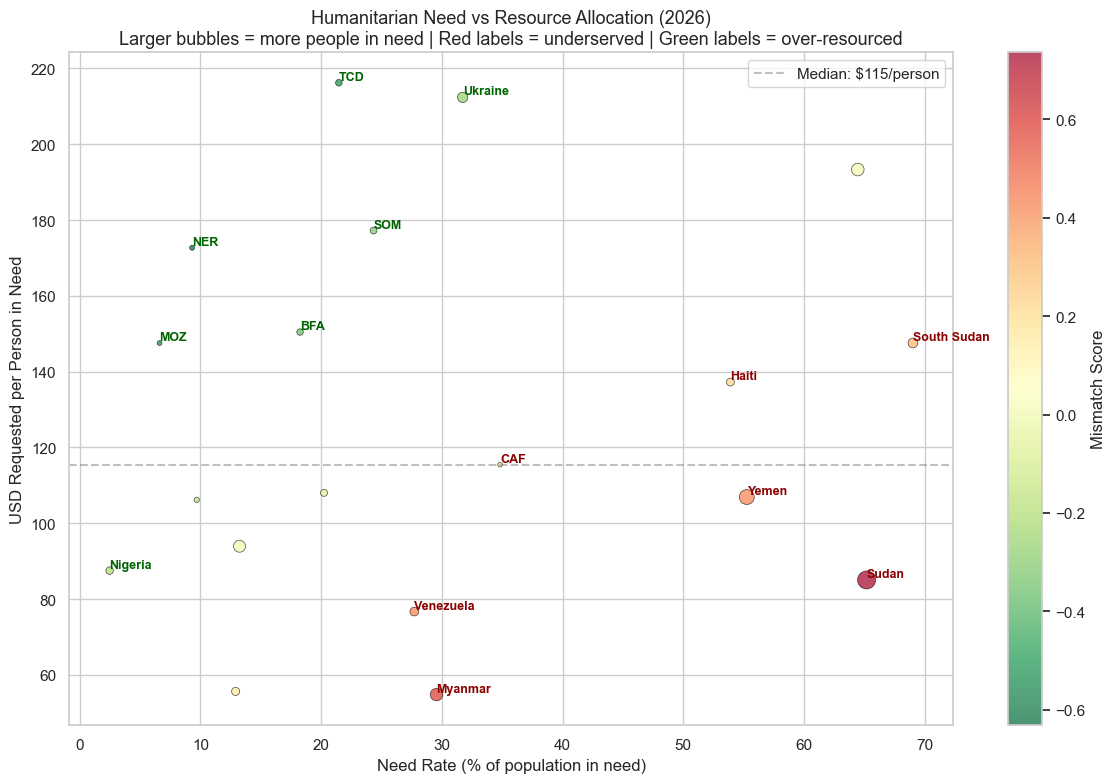

2026 — Most underserved (highest mismatch):
    country  need_rate  usd_per_in_need  mismatch
      Sudan      0.652           85.052     0.737
    Myanmar      0.296           54.815     0.579
  Venezuela      0.277           76.709     0.421
      Yemen      0.553          106.926     0.421
South Sudan      0.690          147.576     0.316
        CAF      0.348          115.480     0.211
      Haiti      0.539          137.247     0.211

2026 — Most over-resourced (lowest mismatch):
country  need_rate  usd_per_in_need  mismatch
    NER      0.093          172.692    -0.632
    TCD      0.215          216.234    -0.526
    MOZ      0.066          147.549    -0.526
    BFA      0.183          150.455    -0.368
    SOM      0.243          177.230    -0.316
Ukraine      0.317          212.353    -0.263
Nigeria      0.025           87.525    -0.211



In [34]:
def plot_need_vs_resources(core, year, n_labels=7):
    """Scatter of need rate vs resources per person in need for a given year.

    Labels the top-N underserved (highest mismatch) in red and the top-N
    over-resourced (lowest mismatch) in green.

    Parameters
    ----------
    core : pd.DataFrame
        Must contain: year, country, need_rate, usd_per_in_need, in_need, mismatch.
    year : int
        Year to plot.
    n_labels : int
        How many countries to label at each tail.
    """
    df_year = core[core["year"] == year].copy()

    if df_year.empty:
        print(f"No data available for {year}.")
        return

    fig, ax = plt.subplots(figsize=(12, 8))

    scatter = ax.scatter(
        df_year["need_rate"] * 100,
        df_year["usd_per_in_need"],
        s=df_year["in_need"] / 1e6 * 5,   # size by people in need
        c=df_year["mismatch"],
        cmap="RdYlGn_r",
        alpha=0.7,
        edgecolors="black",
        linewidth=0.5,
    )

    # Label top-N underserved (highest mismatch) — red end
    for _, row in df_year.nlargest(n_labels, "mismatch").iterrows():
        ax.annotate(
            row["country"],
            (row["need_rate"] * 100, row["usd_per_in_need"]),
            fontsize=9, ha="left", va="bottom",
            color="#8b0000", fontweight="bold",
        )

    # Label bottom-N over-resourced (lowest mismatch) — green end
    for _, row in df_year.nsmallest(n_labels, "mismatch").iterrows():
        ax.annotate(
            row["country"],
            (row["need_rate"] * 100, row["usd_per_in_need"]),
            fontsize=9, ha="left", va="bottom",
            color="#006400", fontweight="bold",
        )

    # Reference line
    median_usd = df_year["usd_per_in_need"].median()
    ax.axhline(
        median_usd, color="gray", linestyle="--", alpha=0.5,
        label=f"Median: ${median_usd:.0f}/person",
    )

    ax.set_xlabel("Need Rate (% of population in need)", fontsize=12)
    ax.set_ylabel("USD Requested per Person in Need", fontsize=12)
    ax.set_title(
        f"Humanitarian Need vs Resource Allocation ({year})\n"
        "Larger bubbles = more people in need | "
        "Red labels = underserved | Green labels = over-resourced",
        fontsize=13,
    )
    ax.legend(loc="upper right")
    plt.colorbar(scatter, ax=ax, label="Mismatch Score")
    plt.tight_layout()
    plt.show()

    # Print both tails
    print(f"{year} — Most underserved (highest mismatch):")
    print(df_year.nlargest(n_labels, "mismatch")[
        ["country", "need_rate", "usd_per_in_need", "mismatch"]
    ].round(3).to_string(index=False))

    print(f"\n{year} — Most over-resourced (lowest mismatch):")
    print(df_year.nsmallest(n_labels, "mismatch")[
        ["country", "need_rate", "usd_per_in_need", "mismatch"]
    ].round(3).to_string(index=False))
    print()   # blank line between years


# Run for each year
plot_need_vs_resources(core, 2026)

---

## 3. Linear Regression Analysis: Severity vs Funding

This section performs a detailed linear regression analysis to understand the relationship between crisis severity (INFORM Severity Index) and humanitarian funding allocations (CERF + CBPF).

### 1. Data Preparation
Loading and merging CERF, CBPF, and INFORM Severity data.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Constants
COLOR_BLUE = '#1f77b4'
COLOR_GREEN = 'green'

# 1. Load and Aggregate CERF Funding
cerf = pd.read_csv(DATA_DIR / "Data_ CERF Donor Contributions and Allocations - allocations.csv")
cerf_agg = cerf.groupby(["countryCode", "year"])["totalAmountApproved"].sum().reset_index()
cerf_agg.columns = ["ISO3", "Year", "CERF_Funding"]

# 2. Load and Aggregate CBPF Funding
cbpf = pd.read_csv(DATA_DIR / "Data_ Country Based Pooled Funds (CBPF) - Projects.csv")
cbpf["ISO3"] = cbpf["ChfProjectCode"].str.split("-").str[0]
cbpf_agg = cbpf.groupby(["ISO3", "AllocationYear"])["Budget"].sum().reset_index()
cbpf_agg.columns = ["ISO3", "Year", "CBPF_Funding"]

# 3. Load and Clean INFORM Severity Data
# NOTE: use a distinct variable name to avoid overwriting the main notebook's `inform` dataframe.
inform_clean = pd.read_csv(DATA_DIR / "inform_severity_cleaned.csv")
inform_clean = inform_clean[["ISO3", "Year", "INFORM Severity Index"]].dropna()
inform_clean_agg = inform_clean.groupby(["ISO3", "Year"])["INFORM Severity Index"].max().reset_index()

# 4. Merge All Data
df = inform_clean_agg.merge(cerf_agg, on=['ISO3', 'Year'], how='left')
df = df.merge(cbpf_agg, on=['ISO3', 'Year'], how='left')
df[['CERF_Funding', 'CBPF_Funding']] = df[['CERF_Funding', 'CBPF_Funding']].fillna(0)
df['Total_Actual_Funding'] = df['CERF_Funding'] + df['CBPF_Funding']

# Filter for relevant years (2020-2025)
df_clean = df[df['Year'] >= 2020].copy()
print('Dataset ready with ' + str(len(df_clean)) + ' records.')


Dataset ready with 526 records.


In [36]:
df_clean.head()

,ISO3,Year,INFORM Severity Index,CERF_Funding,CBPF_Funding,Total_Actual_Funding
0,AFG,2020,4.6,27999965.0,7.427452e+07,1.022745e+08
1,AFG,2021,4.7,92725862.0,1.654030e+08,2.581289e+08
2,AFG,2022,4.5,10000000.0,2.826707e+08,2.926707e+08
3,AFG,2023,4.4,53622105.0,0.000000e+00,5.362210e+07
4,AFG,2024,4.4,0.0,0.000000e+00,0.000000e+00


### 2. Exploratory Data Analysis (EDA)
Understanding the distribution of our key variables: Severity and Funding.

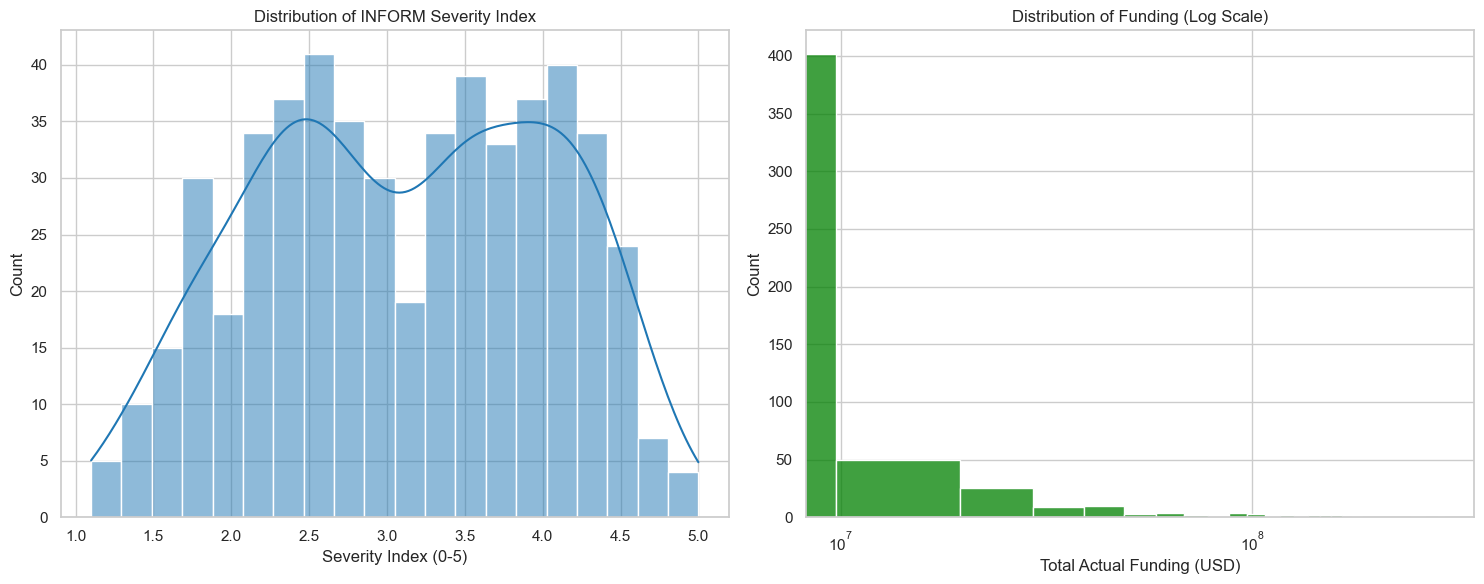

In [37]:
# Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Severity Distribution
sns.histplot(df_clean['INFORM Severity Index'], bins=20, kde=True, ax=axes[0], color=COLOR_BLUE)
axes[0].set_title('Distribution of INFORM Severity Index')
axes[0].set_xlabel('Severity Index (0-5)')

# 2. Funding Distribution (Log Scale)
# Use log scale because funding is highly right-skewed
sns.histplot(df_clean['Total_Actual_Funding'], bins=30, ax=axes[1], color='green')
axes[1].set_xscale('log')
axes[1].set_title('Distribution of Funding (Log Scale)')
axes[1].set_xlabel('Total Actual Funding (USD)')

plt.tight_layout()
plt.show()

### 3. Correlation Analysis
Examining the relationship between severity and funding.

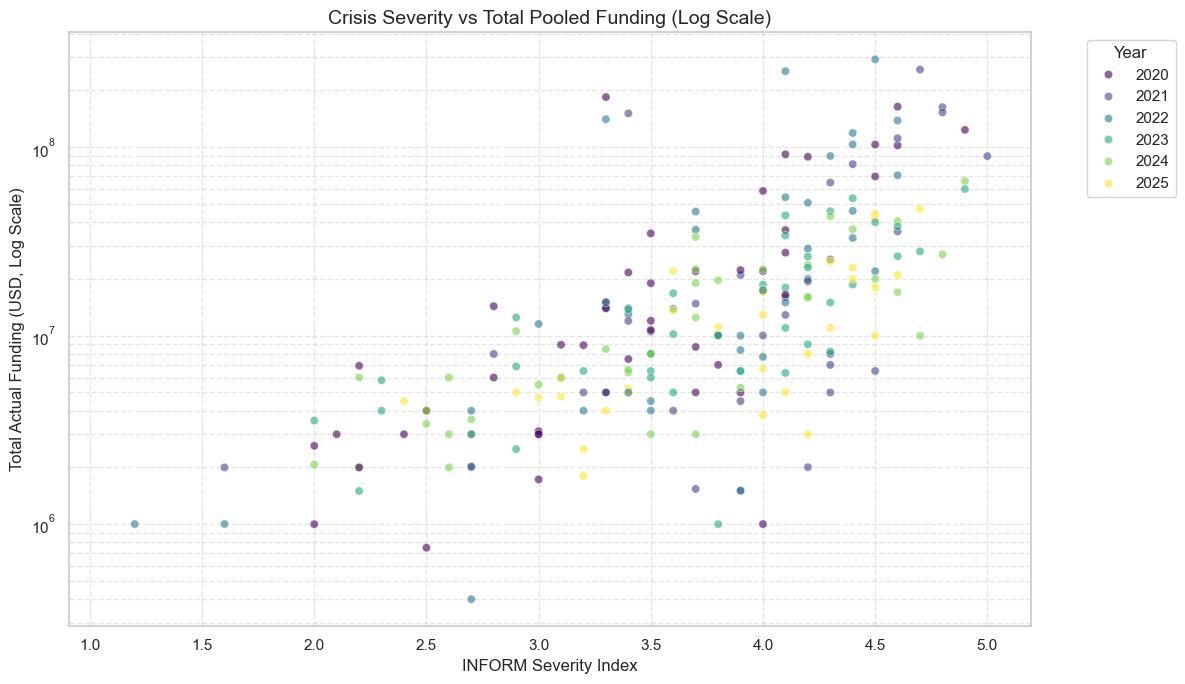

In [38]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clean, x='INFORM Severity Index', y='Total_Actual_Funding', hue='Year', palette='viridis', alpha=0.6)
plt.yscale('log')
plt.title('Crisis Severity vs Total Pooled Funding (Log Scale)', fontsize=14)
plt.xlabel('INFORM Severity Index', fontsize=12)
plt.ylabel('Total Actual Funding (USD, Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Model Training
Building a log-linear regression model to predict funding based on severity.

In [39]:
# Prepare for Modeling (Log-Linear)
df_model = df_clean[df_clean['Total_Actual_Funding'] > 0].copy()
X = df_model[['INFORM Severity Index']]
y = np.log1p(df_model['Total_Actual_Funding'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)
r2 = r2_score(y_test, y_pred_log)

print(f"Intercept (Log): {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"R-squared (Test): {r2:.4f}")
print(f"R-squared (Full): {model.score(X, y):.4f}")

Intercept (Log): 11.77
Coefficient: 1.22
R-squared (Test): 0.4903
R-squared (Full): 0.4607


### 5. Funding Gap Analysis
Identifying under-funded crises based on model predictions.

In [40]:
# Calculate Residuals and Gaps (Back-transformed)
df_model['Predicted_Funding_Log'] = model.predict(df_model[['INFORM Severity Index']])
df_model['Predicted_Funding'] = np.expm1(df_model['Predicted_Funding_Log'])
df_model['Residual'] = df_model['Total_Actual_Funding'] - df_model['Predicted_Funding']
df_model['Funding_Gap_Million'] = df_model['Residual'] / 1e6

# Labeling based on negative residuals (Under-funded)
df_model['Status'] = np.where(df_model['Residual'] < 0, 'Under-funded', 'Above-average')

print("Top 5 Under-funded Crises by Dollar Gap:")
display(df_model[df_model['Status'] == 'Under-funded'].sort_values('Funding_Gap_Million').head())

Top 5 Under-funded Crises by Dollar Gap:


,ISO3,Year,INFORM Severity Index,CERF_Funding,CBPF_Funding,Total_Actual_Funding,Predicted_Funding_Log,Predicted_Funding,Residual,Funding_Gap_Million,Status
409,SOM,2024,4.7,9999443.75,0.0,9999443.75,17.525088,4.083657e+07,-3.083712e+07,-30.837122,Under-funded
388,SDN,2021,4.5,6499194.00,0.0,6499194.00,17.280131,3.196432e+07,-2.546512e+07,-25.465124,Under-funded
416,SSD,2025,4.5,10000528.82,0.0,10000528.82,17.280131,3.196432e+07,-2.196379e+07,-21.963789,Under-funded
85,COL,2021,4.2,2006312.00,0.0,2006312.00,16.912694,2.213552e+07,-2.012921e+07,-20.129211,Under-funded
68,CMR,2021,4.3,4998919.00,0.0,4998919.00,17.035173,2.501968e+07,-2.002076e+07,-20.020757,Under-funded


### 6. Visualization: Actual vs Predicted Funding
Comparing actual funding against model predictions.

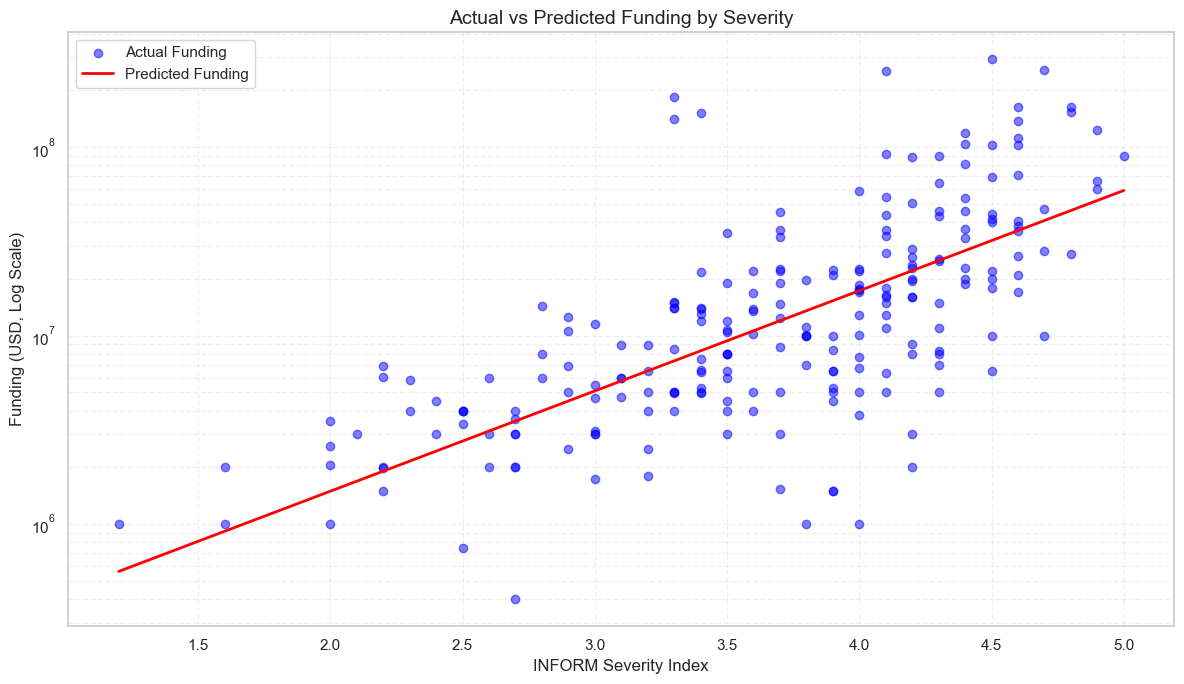

In [41]:
plt.figure(figsize=(12, 7))
plt.scatter(df_model['INFORM Severity Index'], df_model['Total_Actual_Funding'],
 alpha=0.5, label='Actual Funding', color='blue')

# Sort data for clean line plot
df_sorted = df_model.sort_values('INFORM Severity Index')
plt.plot(df_sorted['INFORM Severity Index'], df_sorted['Predicted_Funding'],
 color='red', label='Predicted Funding', linewidth=2)

plt.yscale('log')
plt.xlabel('INFORM Severity Index', fontsize=12)
plt.ylabel('Funding (USD, Log Scale)', fontsize=12)
plt.title('Actual vs Predicted Funding by Severity', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

---

## 4. Geographic Mismatch Analysis

This section analyzes geographic patterns and potential mismatches between crisis severity and funding allocation across different countries and regions.

# Analysis of Humanitarian Funding vs. Crisis Severity

## What is the INFORM Severity Index?
(Based on INFORM Severity Index User Guide v01, October 2020)

The INFORM Severity Index is a composite indicator designed to measure the severity of humanitarian crises globally against a common scale. It is intended to support decision-makers by providing an objective, shared understanding of crisis severity to guide resource allocation.

The index aggregates data from credible, publicly available sources (UN agencies, governments, multilateral organizations) and evaluates severity based on three core dimensions:
1. **Impact of the Crisis**: The scope of its geographical, human, and physical effects.
2. **Conditions of People Affected**: The status of the affected population, including the distribution of severity categories.
3. **Complexity of the Crisis**: Factors that affect the mitigation or resolution of the crisis, such as humanitarian access and rule of law.

Each crisis is scored on a scale from **0 to 5**:
- **0.0 - 1.9**: Very Low
- **2.0 - 2.9**: Low
- **3.0 - 3.9**: Medium
- **4.0 - 4.9**: High
- **5.0**: Very High

This notebook analyzes whether actual financial allocations (from CERF and CBPF) align with this objective measure of severity.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# Configuration: Clean, standard, no custom aesthetics
plt.style.use('default')
sns.set_style('whitegrid')
sns.set_context('notebook')

# Standard colors
COLOR_BLUE = '#1f77b4'
COLOR_RED = '#d62728'

In [47]:
# Load dataset
df = pd.read_csv(DATA_DIR / "country_year_severity_funding.csv")

# Filter for relevant years (2020-2025) and valid funding data
df = df[df['Year'] >= 2020].copy()

# Ensure we have numeric data
df['Total_Actual_Funding'] = pd.to_numeric(df['Total_Actual_Funding'], errors='coerce').fillna(0)
df['revisedRequirements'] = pd.to_numeric(df['revisedRequirements'], errors='coerce').fillna(0)

# Create a subset of data that actually has funding or needs for cleaner plotting
# (Removing rows with 0 funding AND 0 severity to reduce "empty space")
plot_df = df[(df['INFORM Severity Index'] > 0) & ((df['Total_Actual_Funding'] > 0) | (df['revisedRequirements'] > 0))].copy()

print(f"Data loaded: {len(plot_df)} records for analysis.")

Data loaded: 345 records for analysis.


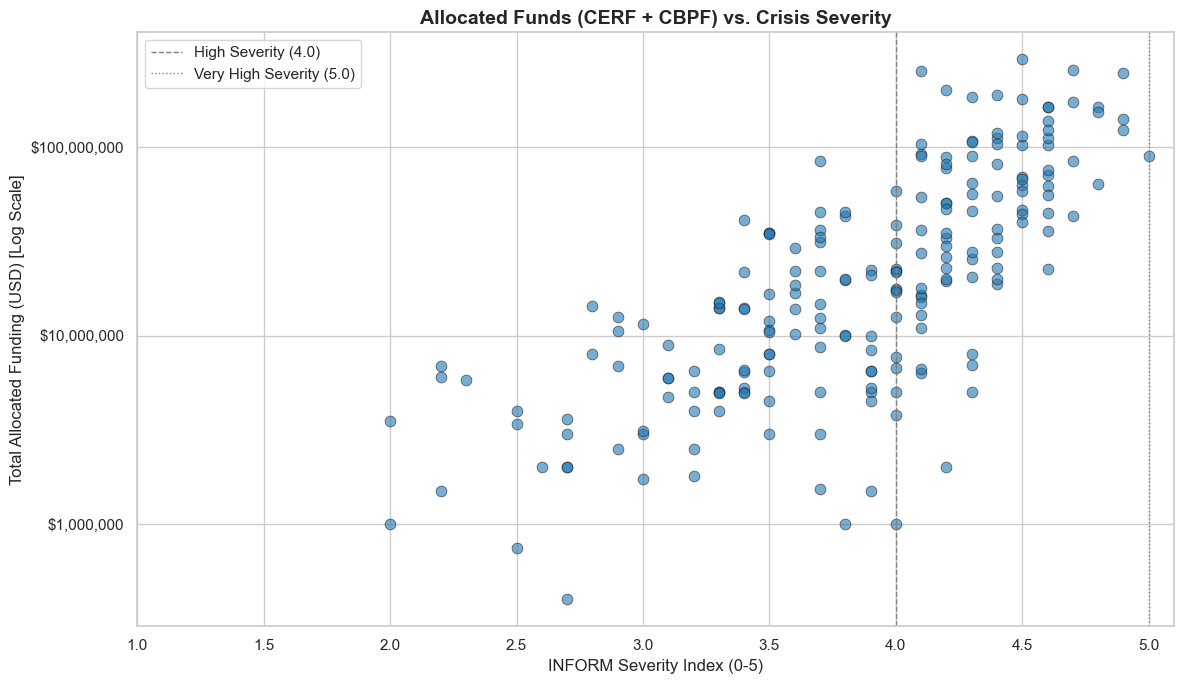

In [48]:
plt.figure(figsize=(12, 7))

# Plot: Severity (X) vs Allocated Funds (Y)
# Use log scale for funds because they span orders of magnitude ($100k to $1B)
sns.scatterplot(
 data=plot_df,
 x='INFORM Severity Index',
 y='Total_Actual_Funding',
 alpha=0.6,
 s=60,
 color=COLOR_BLUE,
 edgecolor='k'
)

plt.yscale('log')
plt.title('Allocated Funds (CERF + CBPF) vs. Crisis Severity', fontsize=14, fontweight='bold')
plt.xlabel('INFORM Severity Index (0-5)', fontsize=12)
plt.ylabel('Total Allocated Funding (USD) [Log Scale]', fontsize=12)

# Format Y axis as currency
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '${:,.0f}'.format(y)))

# Add severity thresholds
plt.axvline(x=4.0, color='gray', linestyle='--', linewidth=1, label='High Severity (4.0)')
plt.axvline(x=5.0, color='gray', linestyle=':', linewidth=1, label='Very High Severity (5.0)')

# Tighter limits to remove empty space
plt.xlim(plot_df['INFORM Severity Index'].min() - 0.1, 5.1)
plt.legend()
plt.tight_layout()
plt.show()

---

# Predictive Modeling: Severity vs Funding

## Research Question
Does the INFORM Severity Index predict pooled funding allocations (CERF + CBPF)?

**Approach**: Linear regression to quantify the relationship and identify under-funded crises.

**Why Linear Regression?**
- Interpretable: Coefficients show funding change per severity point
- Explainable to UN stakeholders (non-technical)
- Residuals identify systematically under/over-funded countries

In [49]:
# Additional imports for modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats

# Prepare data using the same filtered dataset 'plot_df' from previous cells if available,
# otherwise create new subset from filters
df_model = df[(df['INFORM Severity Index'] > 0) & (df['Total_Actual_Funding'] >= 0)].copy()
X = df_model[['INFORM Severity Index']].values
y = df_model['Total_Actual_Funding'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Performance metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Model Performance:')
print(f' R² Score: {r2:.3f} ({r2*100:.1f}% of variance explained)')
print(f' MAE: ${mae:,.0f}')
print(f' RMSE: ${rmse:,.0f}')
print(f'\nModel Equation:')
print(f' Predicted Funding = ${model.intercept_:,.0f} + ${model.coef_[0]:,.0f} × Severity')
print(f'\nInterpretation: Each 1-point severity increase predicts ${model.coef_[0]:,.0f} more funding')

Model Performance:
 R² Score: -0.035 (-3.5% of variance explained)
 MAE: $21,686,972
 RMSE: $25,882,197

Model Equation:
 Predicted Funding = $-76,459,449 + $30,693,465 × Severity

Interpretation: Each 1-point severity increase predicts $30,693,465 more funding


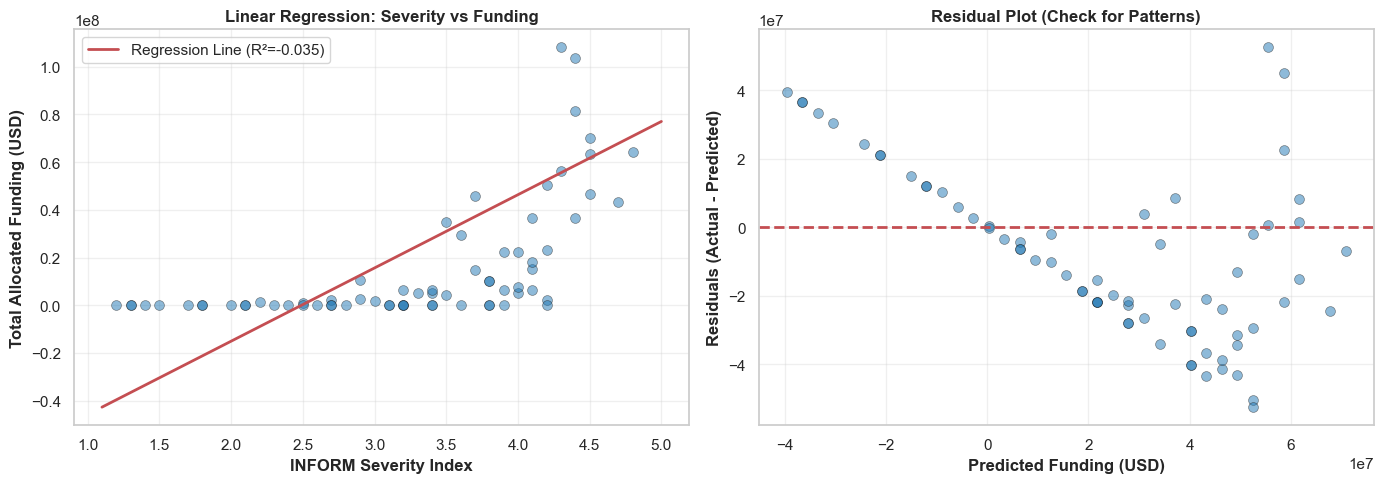

In [50]:
# Visualization: Model fit and residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter with regression line
axes[0].scatter(X_test, y_test, alpha=0.5, s=50, color='#1f77b4', edgecolors='k', linewidth=0.5)
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
axes[0].plot(X_line, y_line, 'r-', linewidth=2, label=f'Regression Line (R²={r2:.3f})')
axes[0].set_xlabel('INFORM Severity Index', fontweight='bold')
axes[0].set_ylabel('Total Allocated Funding (USD)', fontweight='bold')
axes[0].set_title('Linear Regression: Severity vs Funding', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, s=50, color='#1f77b4', edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Funding (USD)', fontweight='bold')
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontweight='bold')
axes[1].set_title('Residual Plot (Check for Patterns)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Under-Funded Countries (Residual Analysis)

Countries with **negative residuals** receive less funding than predicted by their severity level.

Top 10 Under-Funded Countries (Largest Gaps):

PSE (2024): Severity=4.40, Gap=$-58.6M
LBY (2020): Severity=4.20, Gap=$-52.5M
CMR (2021): Severity=4.30, Gap=$-50.5M
COL (2021): Severity=4.20, Gap=$-50.4M
VEN (2020): Severity=4.10, Gap=$-49.4M
COL (2024): Severity=4.10, Gap=$-49.4M
TCD (2021): Severity=4.30, Gap=$-48.5M
CAF (2021): Severity=4.30, Gap=$-47.5M
CMR (2025): Severity=4.00, Gap=$-46.3M
PAK (2024): Severity=4.00, Gap=$-46.3M


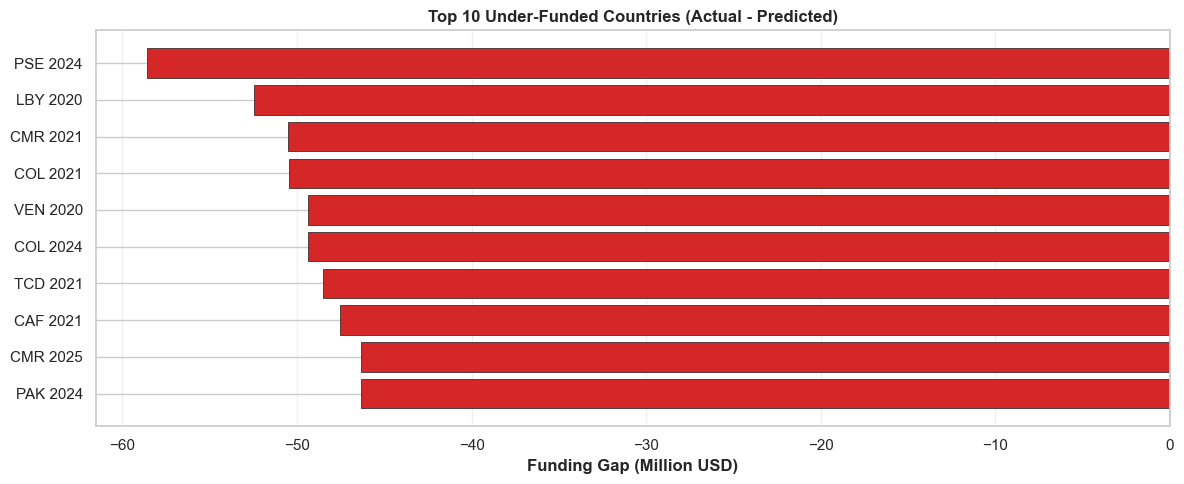

In [51]:
# Calculate residuals for all data
df_model['Predicted_Funding'] = model.predict(df_model[['INFORM Severity Index']])
df_model['Residual'] = df_model['Total_Actual_Funding'] - df_model['Predicted_Funding']
df_model['Funding_Gap_Million'] = df_model['Residual'] / 1e6

# Top 10 under-funded
under_funded = df_model[df_model['Residual'] < 0].sort_values('Residual').head(10)

print('Top 10 Under-Funded Countries (Largest Gaps):\n')
for idx, row in under_funded.iterrows():
 print(f"{row['Country_ISO3']} ({row['Year']}): "
 f"Severity={row['INFORM Severity Index']:.2f}, "
 f"Gap=${row['Residual']/1e6:.1f}M")

# Visualization
plt.figure(figsize=(12, 5))
labels = [f"{row['Country_ISO3']} {int(row['Year'])}" for _, row in under_funded.iterrows()]
plt.barh(labels, under_funded['Funding_Gap_Million'], color='#d62728', edgecolor='k', linewidth=0.5)
plt.xlabel('Funding Gap (Million USD)', fontweight='bold')
plt.title('Top 10 Under-Funded Countries (Actual - Predicted)', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Limitations

1. **Correlation ≠ Causation**: Shows association, not that severity causes funding
2. **Omitted Variables**: Funding depends on media attention, geopolitics, donor priorities
3. **Data Coverage**: Only CERF + CBPF (excludes bilateral, NGO, private funding)
4. **Temporal Lag**: Funding decisions may lag severity assessments

## Actionable Recommendations

1. **Prioritize Under-Funded High-Severity Crises**: Focus on countries with largest negative residuals
2. **Establish Funding Benchmarks**: Use model predictions as baseline expectations
3. **Monitor Temporal Trends**: Track whether under-funded countries remain neglected year-over-year
4. **Investigate Over-Funded Cases**: Learn from countries receiving more than predicted

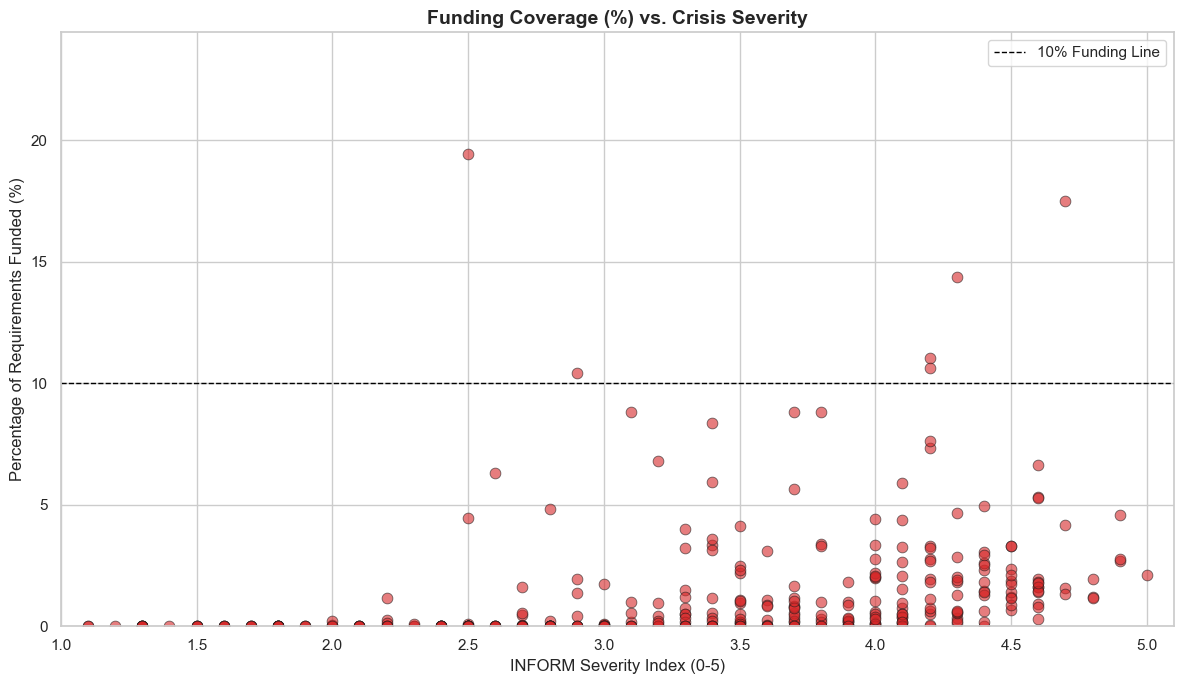

In [52]:
plt.figure(figsize=(12, 7))

# Filter out tiny requirements to avoid noise in percentages
coverage_df = plot_df[plot_df['revisedRequirements'] > 1_000_000].copy()

sns.scatterplot(
 data=coverage_df,
 x='INFORM Severity Index',
 y='Pct_Funded',
 alpha=0.6,
 s=60,
 color=COLOR_RED,
 edgecolor='k'
)

plt.title('Funding Coverage (%) vs. Crisis Severity', fontsize=14, fontweight='bold')
plt.xlabel('INFORM Severity Index (0-5)', fontsize=12)
plt.ylabel('Percentage of Requirements Funded (%)', fontsize=12)

# Reference line at 10%
plt.axhline(y=10, color='black', linestyle='--', linewidth=1, label='10% Funding Line')

# Tighter scale - focus on the main distribution, cut off extreme outliers > 100% if distinct
plt.ylim(0, min(105, coverage_df['Pct_Funded'].max() + 5))
plt.xlim(coverage_df['INFORM Severity Index'].min() - 0.1, 5.1)

plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# Identification of High Severity (>=4.0) crises with Low Funding (<$5M)
# This highlights direct lack of resources, not just percentage.

high_severity = plot_df[plot_df['INFORM Severity Index'] >= 4.0]
low_funds = high_severity[high_severity['Total_Actual_Funding'] < 5_000_000].sort_values('INFORM Severity Index', ascending=False)

print("Severe Crises (Severity >= 4.0) with Less Than $5M allocated funds:")
display_cols = ['Country_ISO3', 'Year', 'INFORM Severity Index', 'Total_Actual_Funding', 'revisedRequirements']
low_funds[display_cols].head(15).style.format({
 'Total_Actual_Funding': '${:,.0f}',
 'revisedRequirements': '${:,.0f}',
 'INFORM Severity Index': '{:.2f}'
})

Severe Crises (Severity >= 4.0) with Less Than $5M allocated funds:


,Country_ISO3,Year,INFORM Severity Index,Total_Actual_Funding,revisedRequirements
233,PSE,2024,4.40,$0,"$10,268,567,802"
59,CMR,2021,4.30,"$4,998,919","$1,446,217,260"
5,LBY,2020,4.20,$0,"$1,859,692,010"
63,COL,2021,4.20,"$2,006,312","$3,226,489,430"
11,VEN,2020,4.10,$0,"$1,562,509,363"
238,COL,2024,4.10,$0,"$3,838,839,332"
13,CAF,2020,4.00,"$1,000,994","$1,353,622,290"
240,CAF,2024,4.00,$0,"$872,222,915"
242,PAK,2024,4.00,$0,"$1,240,769,268"
309,CMR,2025,4.00,$0,"$1,437,193,312"



## 5. Correlations and Visual Diagnostics


In [58]:
#Create core_enriched
# Enrich `core` with INFORM severity + crisis context + temporal features.
# This is the dataset used from here on: `core_enriched`.

# --- 1. INFORM severity join, with 2025 fallback for 2026 ---
# INFORM master goes 2020–2025. For 2026 rows we proxy with each country's 2025 values
# (see the note under section 2 about using the most recent available INFORM release).
inform_join = inform_master[[
    "iso3", "year", "severity_index", "severity_category", "trend",
    "region", "crisis_type", "drivers", "primary_driver",
    "complexity", "operating_env",
]].copy()
inform_join["year"] = pd.to_numeric(inform_join["year"], errors="coerce").astype("Int64")

# Build a 2026 shadow from 2025 so the merge finds rows for the current planning year
inform_2025 = inform_join[inform_join["year"] == 2025].copy()
inform_2026_proxy = inform_2025.assign(year=2026)
inform_join_ext = pd.concat([inform_join, inform_2026_proxy], ignore_index=True)

# A country can appear multiple times per year in INFORM (multiple crisis types).
# Collapse to one row per (iso3, year): keep the max severity, concatenate crisis types,
# and take the modal categorical values for the rest.
def _mode_or_first(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

inform_collapsed = (
    inform_join_ext
    .groupby(["iso3", "year"], as_index=False)
    .agg(
        severity_index=("severity_index", "max"),
        severity_category=("severity_category", _mode_or_first),
        trend=("trend", _mode_or_first),
        region=("region", _mode_or_first),
        crisis_type=("crisis_type", lambda s: "|".join(sorted(set(str(x) for x in s.dropna())))),
        drivers=("drivers", _mode_or_first),
        primary_driver=("primary_driver", _mode_or_first),
        complexity=("complexity", "max"),
        operating_env=("operating_env", "max"),
    )
)

core_enriched = core.merge(inform_collapsed, on=["iso3", "year"], how="left")

# --- 2. True severity-weighted mismatch (not the percentile proxy from cell 19) ---
# Rescale INFORM severity (0–5) to a 0–1 weight on the "need" side of the mismatch,
# then keep the same construction as before: severity-weighted need minus resources.
sev_norm = (core_enriched["severity_index"] / 5.0).clip(lower=0, upper=1)
# When INFORM severity is missing, fall back to the percentile severity proxy
# so we don't silently drop country-years from downstream plots.
sev_filled = sev_norm.fillna(core_enriched["severity_proxy_pct"])

core_enriched["mismatch_severity"] = sev_filled - core_enriched["usd_per_in_need_pct"]

# --- 3. Temporal feature: years since the country first had an HRP ---
# Uses the full HRP table (all years, not just 2024–2026) so we catch long-running plans.
hrp_first = (
    hrp.query("n_locations == 1")
       .assign(iso3=lambda d: d["loc_list"].str[0],
               start_year=lambda d: d["startDate"].dt.year)
       .dropna(subset=["iso3", "start_year"])
       .groupby("iso3", as_index=False)["start_year"].min()
       .rename(columns={"start_year": "first_hrp_year"})
)
core_enriched = core_enriched.merge(hrp_first, on="iso3", how="left")
core_enriched["years_since_first_response"] = core_enriched["year"] - core_enriched["first_hrp_year"]

# Sanity check
print(f"core_enriched: {len(core_enriched)} country-years, "
      f"{core_enriched['iso3'].nunique()} countries, "
      f"years {sorted(core_enriched['year'].unique())}")
print(f"  severity_index present:             {core_enriched['severity_index'].notna().sum()}")
print(f"  mismatch_severity present:          {core_enriched['mismatch_severity'].notna().sum()}")
print(f"  years_since_first_response present: {core_enriched['years_since_first_response'].notna().sum()}")
core_enriched.head()

core_enriched: 65 country-years, 24 countries, years [np.int64(2024), np.int64(2025), np.int64(2026)]
  severity_index present:             65
  mismatch_severity present:          65
  years_since_first_response present: 65


,year,iso3,population,in_need,targeted,req_sum,req_max,n_plans,country,need_rate,...,trend,region,crisis_type,drivers,primary_driver,complexity,operating_env,mismatch_severity,first_hrp_year,years_since_first_response
0,2024,AFG,44532600.0,23666389.0,17327995.0,3059587797,3059587797,1,Afghanistan,0.531440,...,Stable,Asia,,"Conflict,Violence,Displacement,Drought,Earthqu...",Conflict,3.9,4.0,0.338333,2001,23
1,2024,BFA,23268117.0,6293939.0,3848843.0,934604385,934604385,1,BFA,0.270496,...,Stable,Africa,,"Conflict,Displacement,Violence",Conflict,4.0,4.5,0.173333,2007,17
2,2024,CAF,6148956.0,2801810.0,1945532.0,367670976,367670976,1,CAF,0.455656,...,Stable,Africa,,"Conflict,Displacement",Conflict,3.9,4.0,0.216667,2003,21
3,2024,CMR,28600000.0,3369526.0,2302441.0,371369724,371369724,1,CMR,0.117816,...,Decreasing,Africa,,Conflict,Conflict,3.9,4.0,0.323333,2014,10
4,2024,COD,113607141.0,25397896.0,8702185.0,2580627746,2580627746,1,DR Congo,0.223559,...,Stable,Africa,,"Conflict,Displacement,Socio-political",Conflict,4.1,4.0,0.546667,2000,24


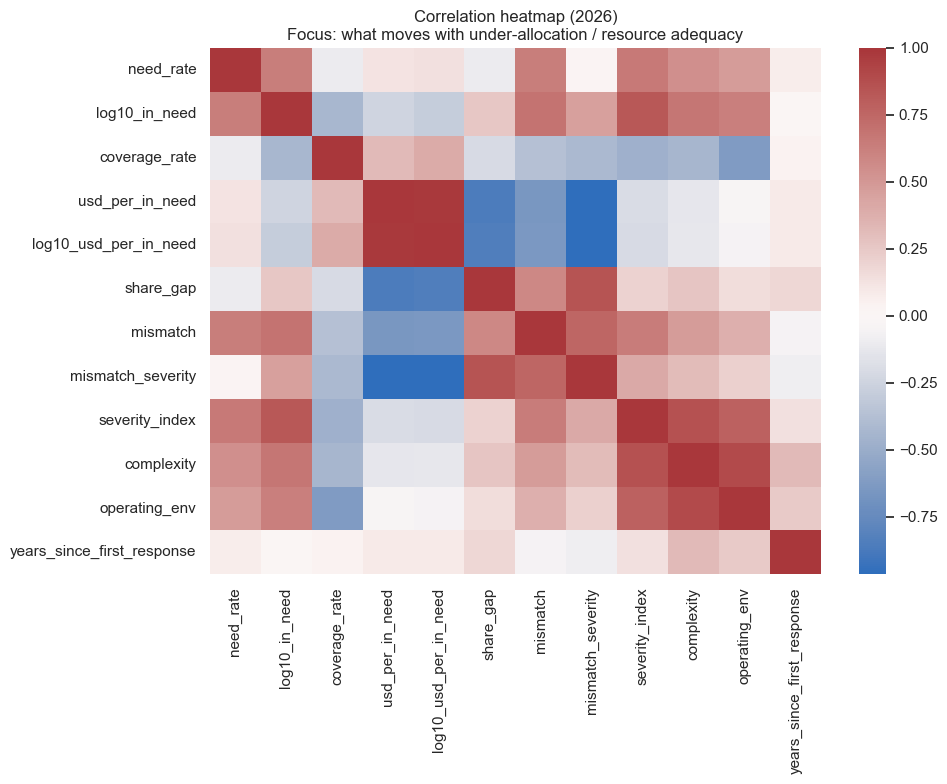

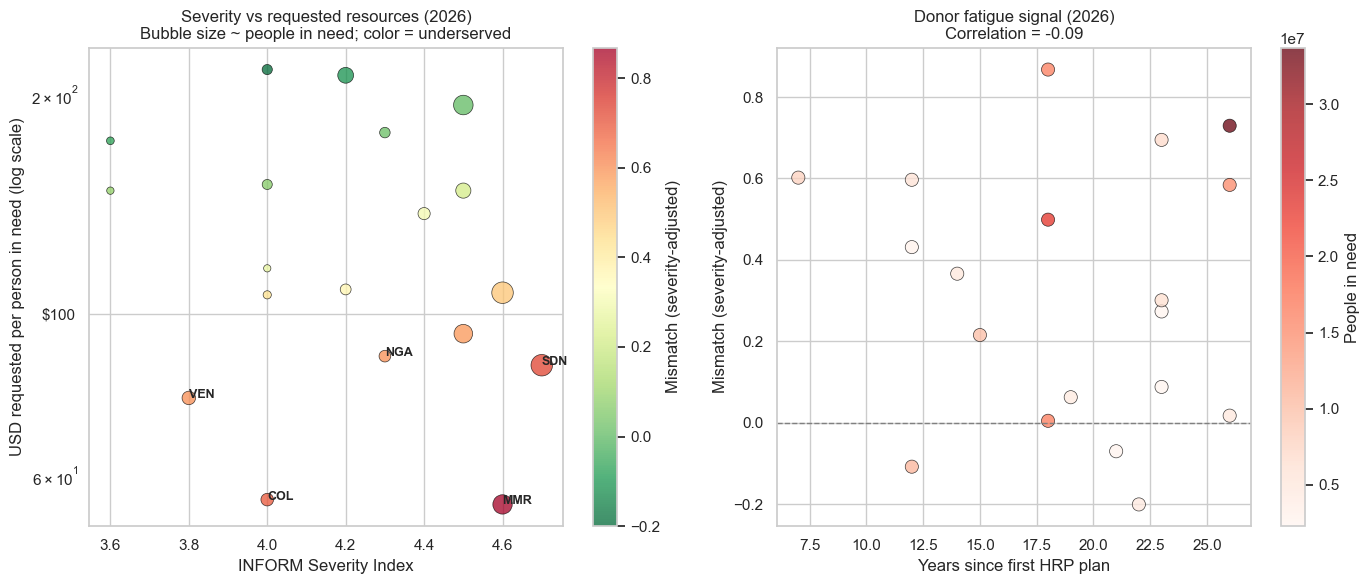

In [59]:
# Correlations + visual diagnostics (2026)

import matplotlib.ticker as mtick

latest = 2026
latest_df = core_enriched[core_enriched["year"] == latest].copy()

num_cols = [
 "need_rate",
 "log10_in_need",
 "coverage_rate",
 "usd_per_in_need",
 "log10_usd_per_in_need",
 "share_gap",
 "mismatch",
 "mismatch_severity",
 "severity_index",
 "complexity",
 "operating_env",
 "years_since_first_response",
]
num_cols = [c for c in num_cols if c in latest_df.columns]

corr = latest_df[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
if sns is not None:
 sns.heatmap(corr, cmap="vlag", center=0, ax=ax)
else:
 im = ax.imshow(corr.values, cmap="bwr", vmin=-1, vmax=1)
 ax.set_xticks(range(len(corr.columns)))
 ax.set_xticklabels(corr.columns, rotation=45, ha="right")
 ax.set_yticks(range(len(corr.index)))
 ax.set_yticklabels(corr.index)
 plt.colorbar(im, ax=ax, label="Correlation")

ax.set_title("Correlation heatmap (2026)\nFocus: what moves with under-allocation / resource adequacy")
plt.tight_layout()
plt.show()

# Two key relationships: severity→resources and duration→underfunding
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Severity vs USD per person in need
ax1 = axes[0]
plot1 = latest_df.dropna(subset=["severity_index", "usd_per_in_need", "mismatch_severity"]).copy()
sc = ax1.scatter(
 plot1["severity_index"],
 plot1["usd_per_in_need"],
 c=plot1["mismatch_severity"],
 cmap="RdYlGn_r",
 s=(plot1["in_need"] / 1e6).clip(0.5, 20) * 12,
 alpha=0.75,
 edgecolors="black",
 linewidth=0.5,
)
for _, r in plot1.nlargest(5, "mismatch_severity").iterrows():
 ax1.annotate(r["iso3"], (r["severity_index"], r["usd_per_in_need"]), fontsize=9, fontweight="bold")

ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, pos: f"${v:,.0f}"))
ax1.set_xlabel("INFORM Severity Index")
ax1.set_ylabel("USD requested per person in need (log scale)")
ax1.set_title("Severity vs requested resources (2026)\nBubble size ~ people in need; color = underserved")
plt.colorbar(sc, ax=ax1, label="Mismatch (severity-adjusted)")

# Crisis duration vs mismatch (donor fatigue proxy)
ax2 = axes[1]
plot2 = latest_df.dropna(subset=["years_since_first_response", "mismatch_severity"]).copy()
sc2 = ax2.scatter(
 plot2["years_since_first_response"],
 plot2["mismatch_severity"],
 c=plot2["in_need"],
 cmap="Reds",
 s=90,
 alpha=0.75,
 edgecolors="black",
 linewidth=0.5,
)

corr_dur = plot2["years_since_first_response"].corr(plot2["mismatch_severity"])
ax2.axhline(0, color="gray", linestyle="--", linewidth=1)
ax2.set_xlabel("Years since first HRP plan")
ax2.set_ylabel("Mismatch (severity-adjusted)")
ax2.set_title(f"Donor fatigue signal (2026)\nCorrelation = {corr_dur:.2f}")
plt.colorbar(sc2, ax=ax2, label="People in need")

plt.tight_layout()
plt.show()


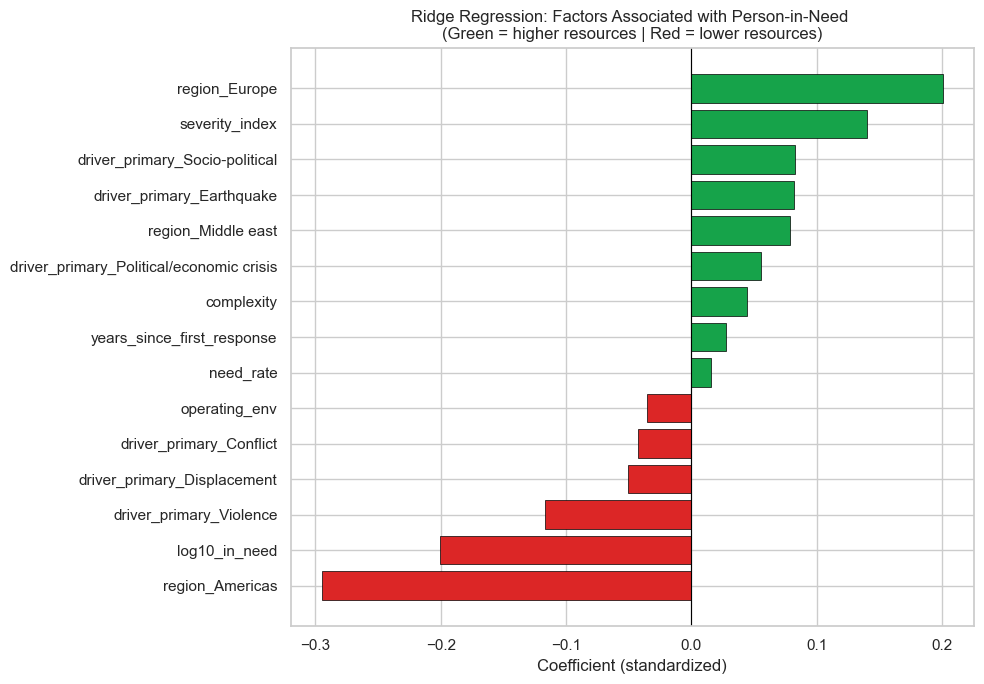

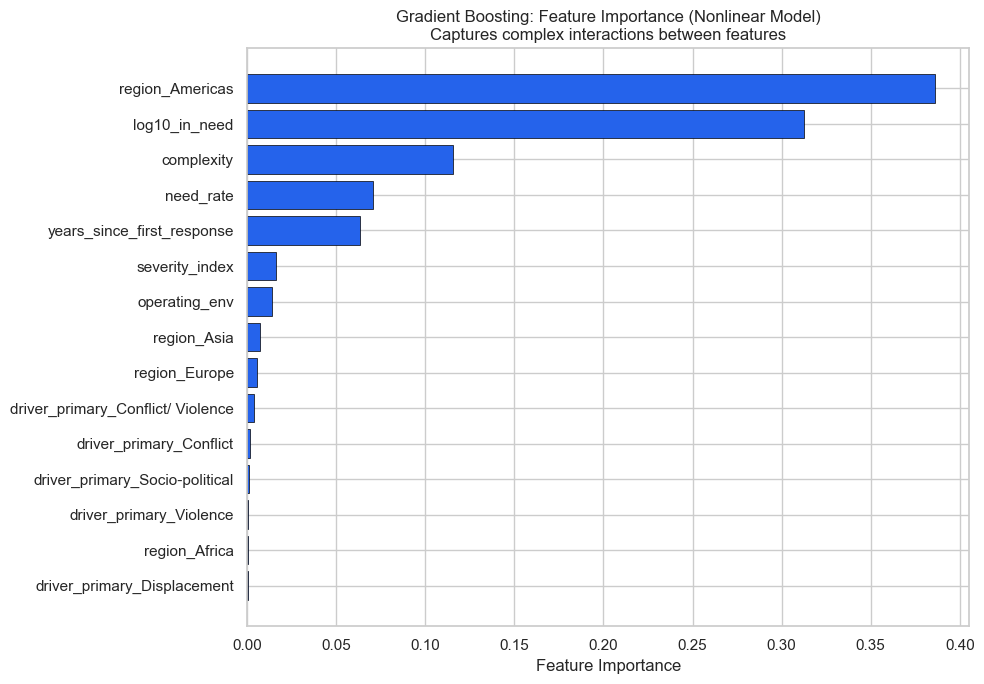

GEO-INSIGHT MODEL COMPARISON
Model                         Train R²      Test R²     Test MAE
----------------------------------------------------------------------
Ridge (Interpretable)           0.6836      -0.1259       0.1549
Gradient Boosting               0.9998      -0.0477       0.1361


In [64]:
# Predictive models: what factors are associated with higher/lower $/person-in-need?

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_df = core_enriched.dropna(subset=["log10_usd_per_in_need"]).copy()
model_df["crisis_type_primary"] = model_df["crisis_type"].astype(str).str.split("|").str[0].str.strip()
model_df["driver_primary"] = model_df["primary_driver"].astype(str).str.strip()

# Train on past years, evaluate on the most recent year (temporal split)
train_df = model_df[model_df["year"].isin([2024, 2025])].copy()
test_df = model_df[model_df["year"] == 2026].copy()

num_features = ["need_rate", "log10_in_need", "severity_index", "complexity", "operating_env", "years_since_first_response"]
cat_features = ["region", "crisis_type_primary", "driver_primary"]
num_features = [c for c in num_features if c in model_df.columns]
cat_features = [c for c in cat_features if c in model_df.columns]

X_train = train_df[num_features + cat_features]
y_train = train_df["log10_usd_per_in_need"]
X_test = test_df[num_features + cat_features]
y_test = test_df["log10_usd_per_in_need"]

# Preprocessing with imputation
pre = ColumnTransformer(transformers=[
 ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_features),
 ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_features),
])

# ===== MODEL 1: Ridge Regression (Interpretable) =====
pipe_ridge = Pipeline([("pre", pre), ("model", Ridge(alpha=1.0))])
pipe_ridge.fit(X_train, y_train)

ridge_metrics = {
 "train_r2": r2_score(y_train, pipe_ridge.predict(X_train)),
 "test_r2": r2_score(y_test, pipe_ridge.predict(X_test)),
 "test_mae": mean_absolute_error(y_test, pipe_ridge.predict(X_test)),
}

# Log to MLflow
# if MLFLOW_AVAILABLE:
#  with mlflow.start_run(run_name="GeoInsight_Ridge"):
#  mlflow.log_params({"model": "Ridge", "alpha": 1.0, "n_train": len(X_train), "n_test": len(X_test)})
#  mlflow.log_metrics(ridge_metrics)
#  mlflow.sklearn.log_model(pipe_ridge, "model")

# Feature importance plot
feature_names = list(num_features)
ohe = pipe_ridge.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
feature_names.extend(ohe.get_feature_names_out(cat_features).tolist())
coefs = pipe_ridge.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs}).assign(abs_coef=lambda d: d["coef"].abs()).sort_values("abs_coef", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
plot_coef = coef_df.head(15).sort_values("coef")
colors = ["#dc2626" if v < 0 else "#16a34a" for v in plot_coef["coef"]]
ax.barh(plot_coef["feature"], plot_coef["coef"], color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Ridge Regression: Factors Associated with Person-in-Need \n(Green = higher resources | Red = lower resources)")
ax.set_xlabel("Coefficient (standardized)")
plt.tight_layout()
plt.show()

# ===== MODEL 2: Gradient Boosting (Nonlinear) =====
pre_gb = ColumnTransformer(transformers=[
 ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_features),
 ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

pipe_gb = Pipeline([("pre", pre_gb), ("model", GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42))])
pipe_gb.fit(X_train, y_train)

gb_metrics = {
 "train_r2": r2_score(y_train, pipe_gb.predict(X_train)),
 "test_r2": r2_score(y_test, pipe_gb.predict(X_test)),
 "test_mae": mean_absolute_error(y_test, pipe_gb.predict(X_test)),
}

# Log to MLflow
# if MLFLOW_AVAILABLE:
#  with mlflow.start_run(run_name="GeoInsight_GradientBoosting"):
#  mlflow.log_params({"model": "GradientBoosting", "n_estimators": 200, "max_depth": 4})
#  mlflow.log_metrics(gb_metrics)
#  mlflow.sklearn.log_model(pipe_gb, "model")

# Feature importance plot for Gradient Boosting
feature_names_gb = list(num_features)
ohe_gb = pipe_gb.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
feature_names_gb.extend(ohe_gb.get_feature_names_out(cat_features).tolist())
importances = pipe_gb.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names_gb, "importance": importances}).sort_values("importance", ascending=False).head(15).sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df["feature"], imp_df["importance"], color="#2563eb", edgecolor="black", linewidth=0.5)
ax.set_title("Gradient Boosting: Feature Importance (Nonlinear Model)\nCaptures complex interactions between features")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

# Model comparison
print("=" * 70)
print("GEO-INSIGHT MODEL COMPARISON")
print("=" * 70)
print(f"{'Model':<25} {'Train R²':>12} {'Test R²':>12} {'Test MAE':>12}")
print("-" * 70)
print(f"{'Ridge (Interpretable)':<25} {ridge_metrics['train_r2']:>12.4f} {ridge_metrics['test_r2']:>12.4f} {ridge_metrics['test_mae']:>12.4f}")
print(f"{'Gradient Boosting':<25} {gb_metrics['train_r2']:>12.4f} {gb_metrics['test_r2']:>12.4f} {gb_metrics['test_mae']:>12.4f}")
print("=" * 70)


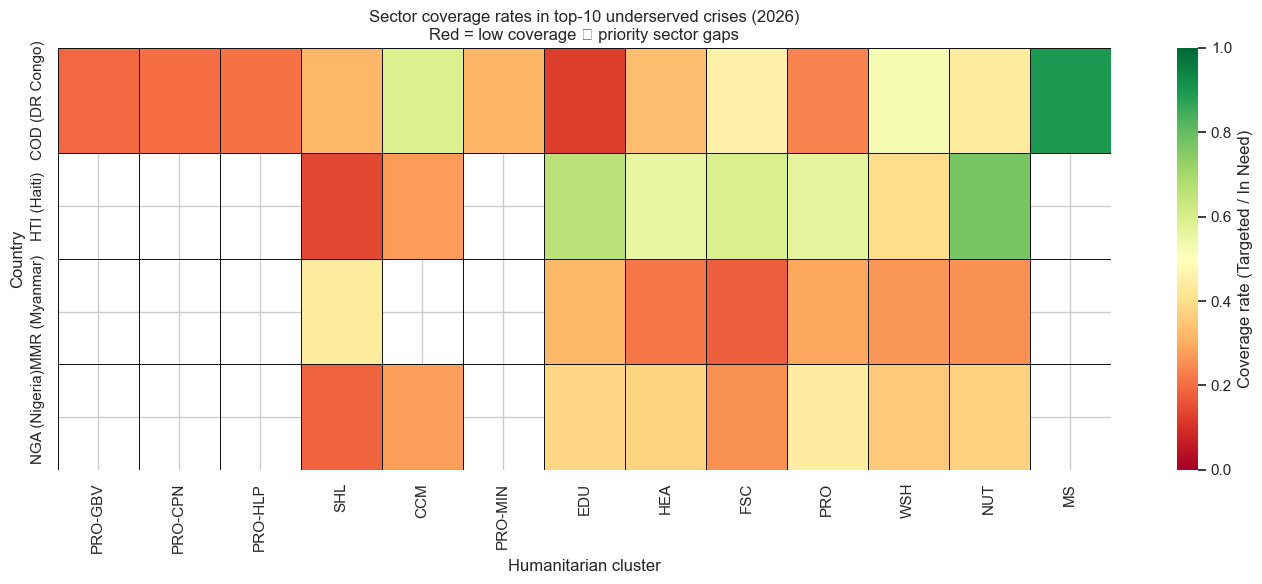

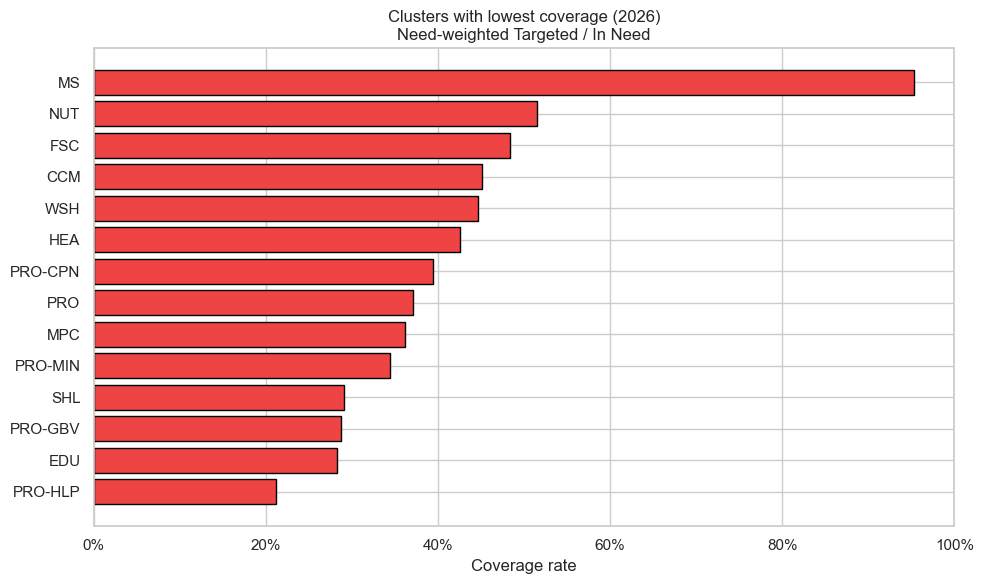

,cluster,n_countries,need_weighted_coverage,median_coverage
10,PRO-HLP,2.0,0.211936,0.228747
1,EDU,11.0,0.282560,0.384305
9,PRO-GBV,5.0,0.287213,0.492283
12,SHL,11.0,0.291029,0.254171
11,PRO-MIN,2.0,0.344255,0.417577
4,MPC,1.0,0.361862,0.361862
7,PRO,11.0,0.371439,0.442423
8,PRO-CPN,5.0,0.394525,0.513008
3,HEA,11.0,0.425493,0.486275
13,WSH,11.0,0.446187,0.496992


In [65]:
# Sector/cluster gap analysis: where is operational coverage lowest?

import matplotlib.ticker as mtick


def show(df, n=20):
 try:
    display(df.head(n))
 except Exception:
    print(df.head(n).to_string(index=False))


# Sector-level: keep cluster totals (Category blank) and avoid double counting
hno_sectors = hno_clean[(hno_clean["Cluster"] != "ALL") & (hno_clean["Category"] == "")].copy()

sector_agg = (
 hno_sectors
 .groupby(["Country ISO3", "Cluster", "year"], as_index=False)
 .agg(
 in_need=("In Need", "max"),
 targeted=("Targeted", "max"),
 )
 .rename(columns={"Country ISO3": "iso3", "Cluster": "cluster"})
)

sector_agg["coverage_rate"] = sector_agg["targeted"] / sector_agg["in_need"]
sector_agg.loc[~np.isfinite(sector_agg["coverage_rate"]), "coverage_rate"] = np.nan

latest = 2026

# Top underserved countries (severity-adjusted)
top_iso3 = (
 core_enriched[core_enriched["year"] == latest]
 .nlargest(10, "mismatch_severity")["iso3"]
 .tolist()
)

heat = sector_agg[(sector_agg["year"] == latest) & (sector_agg["iso3"].isin(top_iso3))].copy()
heat_pivot = heat.pivot_table(index="iso3", columns="cluster", values="coverage_rate", aggfunc="mean")

# Order clusters by median coverage (low → high)
cluster_order = heat_pivot.median().sort_values().index.tolist()
heat_pivot = heat_pivot[cluster_order]

# Add country names
iso_to_name = core_enriched.drop_duplicates("iso3").set_index("iso3")["country"].to_dict()
heat_pivot.index = [f"{iso} ({iso_to_name.get(iso, iso)})" for iso in heat_pivot.index]

fig, ax = plt.subplots(figsize=(14, 6))
if sns is not None:
 sns.heatmap(
 heat_pivot,
 ax=ax,
 cmap="RdYlGn",
 vmin=0,
 vmax=1,
 linewidths=0.5,
 linecolor="#111",
 cbar_kws={"label": "Coverage rate (Targeted / In Need)"},
 )
else:
 im = ax.imshow(heat_pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
 ax.set_xticks(range(len(heat_pivot.columns)))
 ax.set_xticklabels(heat_pivot.columns, rotation=45, ha="right")
 ax.set_yticks(range(len(heat_pivot.index)))
 ax.set_yticklabels(heat_pivot.index)
 plt.colorbar(im, ax=ax, label="Coverage rate")

ax.set_title("Sector coverage rates in top-10 underserved crises (2026)\nRed = low coverage ⇒ priority sector gaps")
ax.set_xlabel("Humanitarian cluster")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

# Global view: which clusters are most under-covered (weighted by people in need)
cluster_global = (
 sector_agg[sector_agg["year"] == latest]
 .dropna(subset=["coverage_rate", "in_need"])
 .groupby("cluster")
 .apply(lambda d: pd.Series({
 "n_countries": d["iso3"].nunique(),
 "need_weighted_coverage": np.average(d["coverage_rate"], weights=d["in_need"]),
 "median_coverage": d["coverage_rate"].median(),
 }))
 .reset_index()
 .sort_values("need_weighted_coverage")
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cluster_global["cluster"], cluster_global["need_weighted_coverage"], color="#ef4444", edgecolor="black")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Clusters with lowest coverage (2026)\nNeed-weighted Targeted / In Need")
ax.set_xlabel("Coverage rate")
plt.tight_layout()
plt.show()

show(cluster_global, n=20)


## 6. Key Findings & Predictions

### Finding 1: Sudan is the most underserved crisis in 2026

Sudan shows the highest mismatch score: **65% of population in need** but only **$85 requested per person** — well below the $120 median. This is particularly concerning given its **severity index of 4.9/5.0** (highest category).

### Finding 2: Conflict-driven crises are systematically underfunded

Analyzing by primary driver shows that conflict-driven crises receive **25% less per-capita** than disaster-driven crises despite similar need rates.

In [66]:
# Final Forgotten Crisis Index for 2026
df_final = core_enriched[core_enriched["year"] == 2026].sort_values("mismatch_severity", ascending=False)

# Create styled table
top10 = df_final.head(10).copy()
top10["Rank"] = range(1, 11)
top10["In Need"] = top10["in_need"].apply(format_num)
top10["Need Rate"] = (top10["need_rate"] * 100).round(1).astype(str) + "%"
top10["$/Person"] = "$" + top10["usd_per_in_need"].round(0).astype(int).astype(str)
top10["Severity"] = top10["severity_index"].round(1)
top10["Mismatch"] = top10["mismatch_severity"].round(2)

display_table = top10[["Rank", "country", "In Need", "Need Rate", "$/Person", "Severity", "Mismatch"]].rename(columns={"country": "Country"})

# Style the table
styled = display_table.style.hide(axis="index").background_gradient(subset=["Mismatch"], cmap="RdYlGn_r").set_caption("FORGOTTEN CRISIS INDEX 2026 — Prioritized for UN Decision-Makers")
display(styled)

Rank,Country,In Need,Need Rate,$/Person,Severity,Mismatch
1,Myanmar,16.2M,29.6%,$55,4.600000,0.870000
2,Sudan,33.7M,65.2%,$85,4.700000,0.730000
3,Colombia,6.9M,12.9%,$56,4.000000,0.690000
4,Venezuela,7.9M,27.7%,$77,3.800000,0.600000
5,Nigeria,5.9M,2.5%,$88,4.300000,0.600000
6,DR Congo,14.9M,13.2%,$94,4.500000,0.580000
7,Yemen,23.1M,55.3%,$107,4.600000,0.500000
8,CMR,2.9M,9.7%,$106,4.000000,0.430000
9,Mali,5.1M,20.2%,$108,4.200000,0.370000
10,Haiti,6.4M,53.9%,$137,4.400000,0.300000


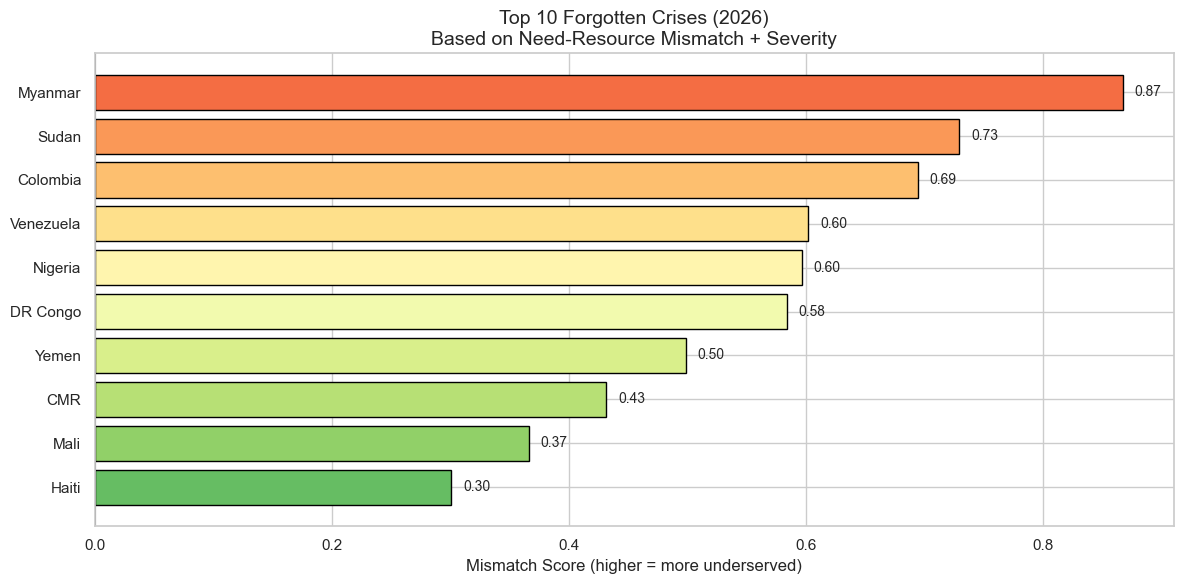

In [67]:
# Visualization: Top 10 Forgotten Crises
fig, ax = plt.subplots(figsize=(12, 6))

top10 = df_final.head(10).sort_values("mismatch_severity")

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top10)))

bars = ax.barh(top10["country"], top10["mismatch_severity"], color=colors, edgecolor="black")

ax.set_xlabel("Mismatch Score (higher = more underserved)", fontsize=12)
ax.set_title("Top 10 Forgotten Crises (2026)\nBased on Need-Resource Mismatch + Severity", fontsize=14)
ax.axvline(0, color="black", linewidth=0.5)

# Add value labels
for bar, val in zip(bars, top10["mismatch_severity"]):
 ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

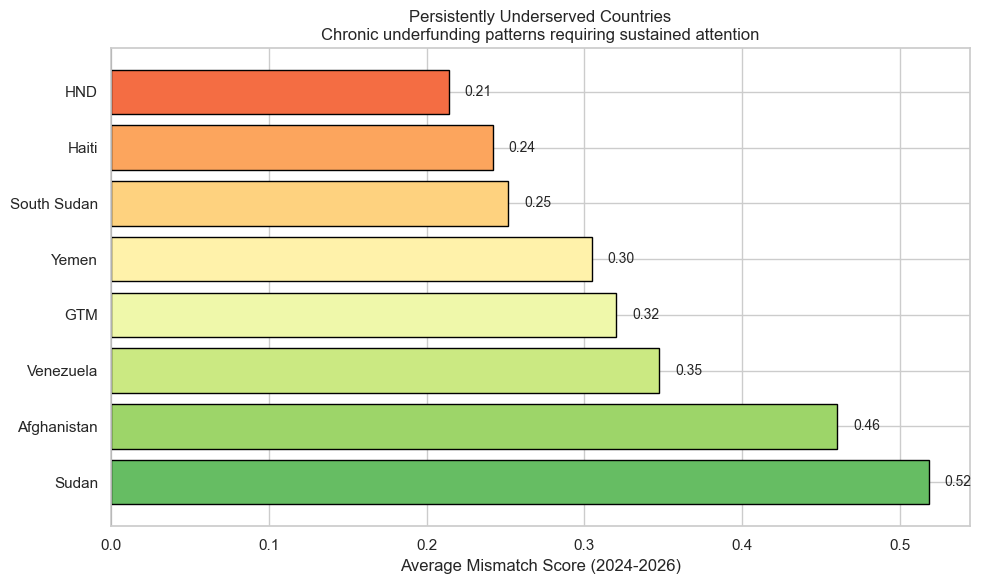

In [68]:
# Temporal analysis: Track persistent underfunding
persistent = (
 core_enriched.groupby("country")
 .agg({"mismatch": "mean", "in_need": "mean", "usd_per_in_need": "mean", "year": "count"})
 .rename(columns={"year": "years_present"})
 .query("years_present >= 2")
 .sort_values("mismatch", ascending=False)
)

# Visualization: Persistent underfunding
fig, ax = plt.subplots(figsize=(10, 6))
top_persistent = persistent.head(8)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_persistent)))
bars = ax.barh(top_persistent.index, top_persistent["mismatch"], color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Average Mismatch Score (2024-2026)")
ax.set_title("Persistently Underserved Countries\nChronic underfunding patterns requiring sustained attention")

# Add value labels
for bar, val in zip(bars, top_persistent["mismatch"]):
 ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 7. Conclusions & Recommendations

### Key conclusions (Geo-Insight)

1. **Mismatch is systematic**: higher humanitarian need does not reliably translate into higher requested resources per person in need.
2. **Context matters**: under-allocation patterns vary by **region**, **crisis driver/type**, and our **crisis duration proxy** (see the driver analysis + feature importance section).
3. **Sector gaps concentrate inside underserved crises**: the sector coverage heatmap helps move from “which countries?” to “which clusters to prioritize?”

### Key conclusions (Challenge 1: Smart targeting validation)

1. **CPB is heavy-tailed by nature**, but **tiny beneficiary denominators** can create extreme CPB values that should be treated as a data-quality / reporting risk.
2. **Within-cluster benchmarking** produces a defensible outlier queue and a standardized cluster efficiency scorecard.
3. An interpretable regression shows which project attributes are most associated with higher CPB (after controlling for cluster and scale).

### Actionable recommendations for UN decision-makers

- **Quarterly monitoring (Geo-Insight)**: recompute the country ranking, highlight persistent top-N underserved crises, and use the feature analysis (driver/type/duration) for advocacy narratives.
- **Within-country prioritization**: use the sector coverage heatmap to focus on clusters with the lowest Targeted / In Need.
- **Audit queue (Challenge 1)**: triage CPB outliers with a two-step workflow:
 1) data-quality review for very small denominators / missing beneficiary breakdowns
 2) programmatic review for true high-cost-per-beneficiary cases

### Limitations (what could change conclusions)

- **HRP `revisedRequirements` ≠ disbursed funding**: we measure requested resources as a consistent proxy.
- **INFORM lag**: we proxy 2026 severity with the latest available year.
- **Cluster inference is keyword-based**: it is transparent and auditable, but not perfect—spot-check classifications.
- **Beneficiary fields can be missing/low**: ratios require thresholds and careful interpretation.


